# COSC2779/COSC2792: Assignment 1
# Drone Marshalling Gesture Recognition

**Student:** Nhat Minh Pham
**Student ID:** s4126779
**Course:** COSC2779/COSC2792, Introduction to Deep Convolutional Neural Networks

---

## Notebook roadmap

This notebook is built incrementally, following the plan below. Part A (Setup through Ultimate Judgment) covers Sections 0 to 7. Part B is the executive summary in Section 8.

0. Reproducibility & environment setup
1. Data exploration
2. Evaluation framework
3. Trivial baselines (majority-class, single-frame CNN)
4. Multi-frame model development
5. Real-time / embedded feasibility analysis
6. Hyper-parameter tuning
7. Final model, results & Ultimate Judgment
8. Part B: Executive summary


## 0. Reproducibility & environment setup

**Why this matters:** the assignment requires a fixed random seed so results are reproducible, and the notebook needs to run cleanly via Restart & Run All on the AWS platform. To make it portable between a local machine (for example Apple Silicon with MPS) and AWS (CUDA), the device is selected automatically instead of hard-coded.

All paths below are relative to the repository root (`data_resized/` sits next to this notebook), so the notebook works unchanged whether it runs locally or after being pulled onto the AWS instance.


In [1]:

import os
import random
import glob
from pathlib import Path
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision import transforms, models

from sklearn.metrics import (
    accuracy_score, f1_score, precision_recall_fscore_support,
    confusion_matrix, classification_report,
)

print(f"torch version:       {torch.__version__}")
print(f"torchvision version: {torchvision.__version__}")


torch version:       2.10.0+cu128
torchvision version: 0.25.0+cu128


In [2]:

# ----------------------------------------------------------------------------
# Global reproducibility settings
# ----------------------------------------------------------------------------
SEED = 42

def set_seed(seed: int = SEED) -> None:
    """Fix every source of randomness we control so results are reproducible
    across re-runs (required by the assignment spec)."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    # Ask cuDNN to behave deterministically (only affects CUDA runs; harmless
    # elsewhere). We do not force `torch.use_deterministic_algorithms(True)`
    # globally because some GPU ops used later (e.g. certain interpolation
    # modes) do not have deterministic kernels, and failing hard there would
    # break "Restart & Run All" on AWS.
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)
print(f"Global seed fixed to {SEED}")


Global seed fixed to 42


In [3]:

# ----------------------------------------------------------------------------
# Device selection: CUDA (AWS) > MPS (Apple Silicon, local dev) > CPU
# ----------------------------------------------------------------------------
def get_device() -> torch.device:
    if torch.cuda.is_available():
        return torch.device("cuda")
    if getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")

DEVICE = get_device()
print(f"Using device: {DEVICE}")


Using device: cuda


In [4]:

# ----------------------------------------------------------------------------
# Dataset location and the 13 gesture classes (fixed, documented order)
# ----------------------------------------------------------------------------
DATA_ROOT = Path("data_resized")

GESTURE_CLASSES = [
    "AllClear", "HaveCommand", "Hover", "Land", "LandingDirection",
    "MoveAhead", "MoveDownward", "MoveToLeft", "MoveToRight", "MoveUpward",
    "NotClear", "SlowDown", "WaveOff",
]
CLASS_TO_IDX = {c: i for i, c in enumerate(GESTURE_CLASSES)}
IDX_TO_CLASS = {i: c for c, i in CLASS_TO_IDX.items()}

assert DATA_ROOT.exists(), (
    f"Could not find '{DATA_ROOT}'. This notebook expects to be run from the "
    f"repository root, with the dataset folder sitting next to it."
)
found_classes = sorted(p.name for p in DATA_ROOT.iterdir() if p.is_dir())
assert found_classes == sorted(GESTURE_CLASSES), (
    f"Class folders on disk do not match the 13 classes in the spec.\n"
    f"On disk: {found_classes}\nExpected: {sorted(GESTURE_CLASSES)}"
)
print(f"Found all {len(GESTURE_CLASSES)} expected class folders under '{DATA_ROOT}/'.")


Found all 13 expected class folders under 'data_resized/'.


## 1. Data exploration

Every downstream design decision (evaluation split, augmentation, model capacity) should be grounded in what the data actually looks like, not assumption. This section builds a full inventory of the dataset directly from the filesystem, so it always reflects the real data rather than a hard-coded summary, then inspects class balance, how instances are distributed across subjects, an example instance, image geometry, and inter-frame motion, including a check for camera shake, which matters for any motion-based features added later.


### 1.1 Directory layout

The dataset (already segmented into 5-frame instances) is organised as:

```
data_resized/<GestureClass>/<Subject>/<Instance>/<frame files ...>
```

Each `<Instance>` folder holds exactly 5 PNG frames, one full gesture performance. `<Subject>` identifies which colleague performed the gesture (for example `S1`, `S3`, ...). This is not a label we predict, but it is critical for building a leak-free evaluation split (Section 2).


In [5]:

# ----------------------------------------------------------------------------
# Walk the dataset once and build a flat inventory: one row per instance.
# ----------------------------------------------------------------------------
def build_instance_index(data_root: Path) -> pd.DataFrame:
    rows = []
    for cls_dir in sorted(data_root.iterdir()):
        if not cls_dir.is_dir():
            continue
        cls = cls_dir.name
        for subj_dir in sorted(cls_dir.iterdir()):
            if not subj_dir.is_dir():
                continue
            subject = subj_dir.name
            for inst_dir in sorted(subj_dir.iterdir()):
                if not inst_dir.is_dir():
                    continue
                frames = sorted(inst_dir.glob("*.png"))
                rows.append({
                    "gesture_class": cls,
                    "subject": subject,
                    "instance": inst_dir.name,
                    "instance_path": str(inst_dir),
                    "n_frames": len(frames),
                    "frame_paths": [str(f) for f in frames],
                })
    return pd.DataFrame(rows)

instance_df = build_instance_index(DATA_ROOT)
print(f"Total instances found: {len(instance_df)}")
instance_df.head()


Total instances found: 1059


,gesture_class,subject,instance,instance_path,n_frames,frame_paths
0,AllClear,S1,Instance1,data_resized/AllClear/S1/Instance1,5,[data_resized/AllClear/S1/Instance1/S1_allClea...
1,AllClear,S1,Instance2,data_resized/AllClear/S1/Instance2,5,[data_resized/AllClear/S1/Instance2/S1_allClea...
2,AllClear,S1,Instance3,data_resized/AllClear/S1/Instance3,5,[data_resized/AllClear/S1/Instance3/S1_allClea...
3,AllClear,S1,Instance4,data_resized/AllClear/S1/Instance4,5,[data_resized/AllClear/S1/Instance4/S1_allClea...
4,AllClear,S1,Instance5,data_resized/AllClear/S1/Instance5,5,[data_resized/AllClear/S1/Instance5/S1_allClea...


In [6]:

# ----------------------------------------------------------------------------
# Sanity check: every instance must contain exactly 5 frames. If some don't,
# we need to know *before* building a Dataset/DataLoader around them.
# ----------------------------------------------------------------------------
bad_instances = instance_df[instance_df["n_frames"] != 5]
print(f"Instances with != 5 frames: {len(bad_instances)}")
if len(bad_instances) > 0:
    display(bad_instances[["gesture_class", "subject", "instance", "n_frames"]])
else:
    print("All instances have exactly 5 frames, as expected from the spec.")


Instances with != 5 frames: 0
All instances have exactly 5 frames, as expected from the spec.


### 1.2 Class balance

We count instances per gesture class. This tells us whether accuracy alone would be a misleading metric, which it would under even mild imbalance with 13 classes, and motivates the metric choice in Section 2.


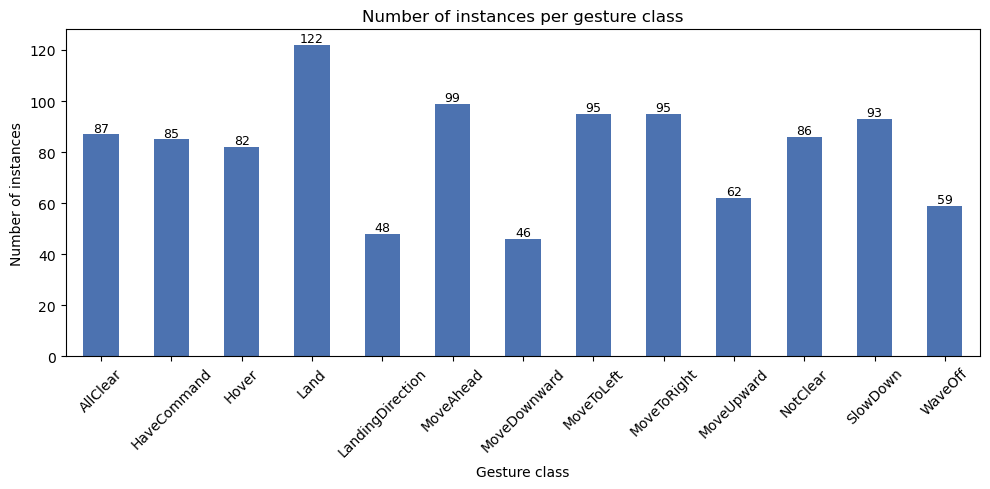

Min class count: 46 (MoveDownward)
Max class count: 122 (Land)
Imbalance ratio (max/min): 2.65x


In [7]:

class_counts = instance_df["gesture_class"].value_counts().reindex(GESTURE_CLASSES)

fig, ax = plt.subplots(figsize=(10, 5))
class_counts.plot(kind="bar", ax=ax, color="#4C72B0")
ax.set_title("Number of instances per gesture class")
ax.set_xlabel("Gesture class")
ax.set_ylabel("Number of instances")
ax.tick_params(axis="x", rotation=45)
for i, v in enumerate(class_counts.values):
    ax.text(i, v + 1, str(v), ha="center", fontsize=9)
plt.tight_layout()
plt.show()

print(f"Min class count: {class_counts.min()} ({class_counts.idxmin()})")
print(f"Max class count: {class_counts.max()} ({class_counts.idxmax()})")
print(f"Imbalance ratio (max/min): {class_counts.max() / class_counts.min():.2f}x")


**Observation to carry forward:** the class distribution is not extreme (roughly a 2 to 3x ratio between the smallest and largest class in typical runs of this dataset), but it is uneven enough that plain accuracy would let a model that is lazy on rare classes look better than it is. This motivates using macro-averaged F1 (which weighs every class equally regardless of frequency) alongside accuracy and a full confusion matrix, decided in Section 2.


### 1.3 Subject coverage: a critical finding for the evaluation split

`subject` is who performed the gesture, not the label. If the same subject appears in both the training set and the test set, the model can partly "recognise the person" (clothing, background, build) rather than the gesture, and the reported performance would be an optimistic estimate that does not reflect the demo-day scenario of an unseen person performing the gesture. We check this carefully before deciding on a split strategy.


In [8]:

# ----------------------------------------------------------------------------
# Which subjects appear at all, and which classes did each subject perform?
# ----------------------------------------------------------------------------
subject_class_matrix = (
    instance_df.groupby(["subject", "gesture_class"]).size().unstack(fill_value=0)
    .reindex(columns=GESTURE_CLASSES, fill_value=0)
)
all_subjects = sorted(subject_class_matrix.index, key=lambda s: int(s[1:]))
subject_class_matrix = subject_class_matrix.reindex(all_subjects)

print(f"Total distinct subjects in the dataset: {len(all_subjects)}")
subject_class_matrix


Total distinct subjects in the dataset: 11


gesture_class,AllClear,HaveCommand,Hover,Land,LandingDirection,MoveAhead,MoveDownward,MoveToLeft,MoveToRight,MoveUpward,NotClear,SlowDown,WaveOff
subject,,,,,,,,,,,,,
S1,8,9,9,17,7,10,8,9,9,10,5,9,9
S3,9,10,0,0,0,10,0,10,9,0,10,9,0
S4,7,7,13,17,7,6,7,7,10,8,6,6,7
S5,6,5,16,17,4,8,6,7,6,7,6,5,6
S6,9,5,13,16,5,10,7,8,9,9,8,7,8
S9,10,9,0,0,0,10,0,10,10,0,7,10,0
S11,9,7,9,19,9,8,5,9,8,9,9,9,9
S12,8,7,11,18,8,10,8,8,9,9,7,10,12
S13,4,9,11,18,8,9,5,9,8,10,9,7,8


In [9]:

# ----------------------------------------------------------------------------
# Flag subjects that did NOT perform all 13 classes -- this matters a lot for
# how we can safely hold subjects out for validation/test.
# ----------------------------------------------------------------------------
full_coverage_subjects = [
    s for s in all_subjects
    if (subject_class_matrix.loc[s] > 0).sum() == len(GESTURE_CLASSES)
]
partial_coverage_subjects = [s for s in all_subjects if s not in full_coverage_subjects]

print(f"Subjects with ALL {len(GESTURE_CLASSES)} classes present: {full_coverage_subjects}")
print(f"Subjects with PARTIAL class coverage: {partial_coverage_subjects}")

if partial_coverage_subjects:
    print("\nClasses each partial-coverage subject is missing:")
    for s in partial_coverage_subjects:
        missing = [c for c in GESTURE_CLASSES if subject_class_matrix.loc[s, c] == 0]
        print(f"  {s}: missing {missing}")


Subjects with ALL 13 classes present: ['S1', 'S4', 'S5', 'S6', 'S11', 'S12', 'S13']
Subjects with PARTIAL class coverage: ['S3', 'S9', 'S14', 'S15']

Classes each partial-coverage subject is missing:
  S3: missing ['Hover', 'Land', 'LandingDirection', 'MoveDownward', 'MoveUpward', 'WaveOff']
  S9: missing ['Hover', 'Land', 'LandingDirection', 'MoveDownward', 'MoveUpward', 'WaveOff']
  S14: missing ['Hover', 'Land', 'LandingDirection', 'MoveDownward', 'MoveUpward', 'WaveOff']
  S15: missing ['Hover', 'Land', 'LandingDirection', 'MoveDownward', 'MoveUpward', 'WaveOff']


**This is a key data-exploration finding that directly shapes the evaluation framework in Section 2.** A subset of subjects only performed a subset of the 13 gestures. Concretely, if a partial-coverage subject were chosen as the held-out test subject, the test set would have zero examples for the classes that subject never performed, making it impossible to evaluate the model on those classes at all. Any subject-based (group) split must therefore draw its validation/test subjects only from the full-coverage subject pool, and treat partial-coverage subjects as train-only, since they still add useful appearance and background diversity for the classes they do cover.


### 1.4 A visual look at one instance

Before designing a network, it helps to actually look at the raw signal: what does a 5-frame instance look like, and is there visible motion across the 5 frames, confirming the task is genuinely a short-motion recognition problem rather than something solvable from a single static pose?


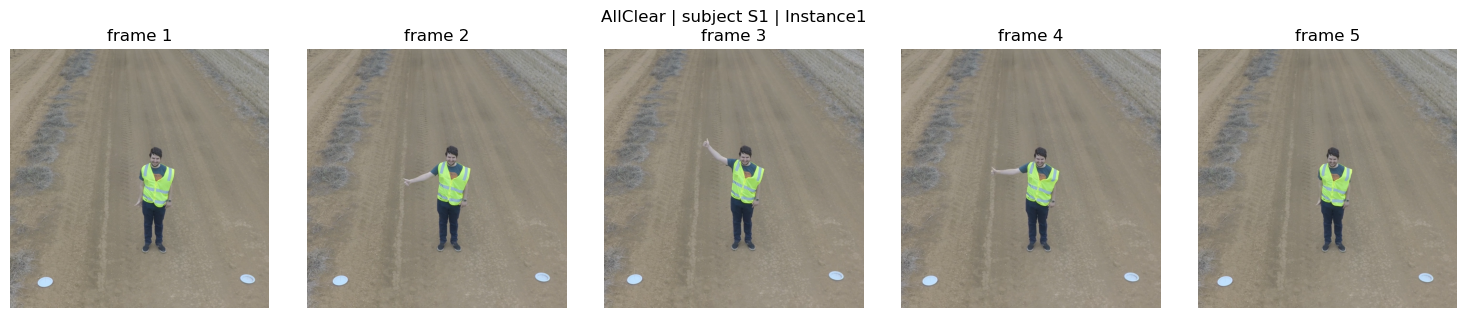

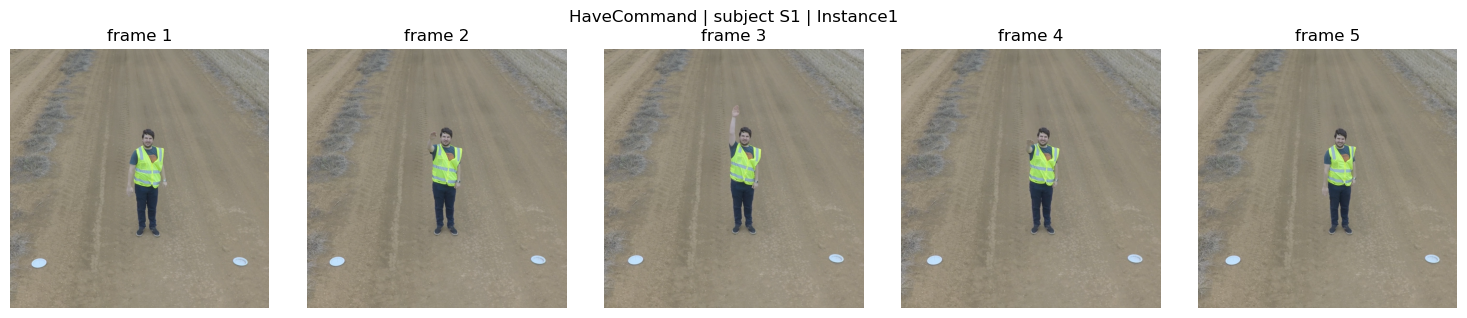

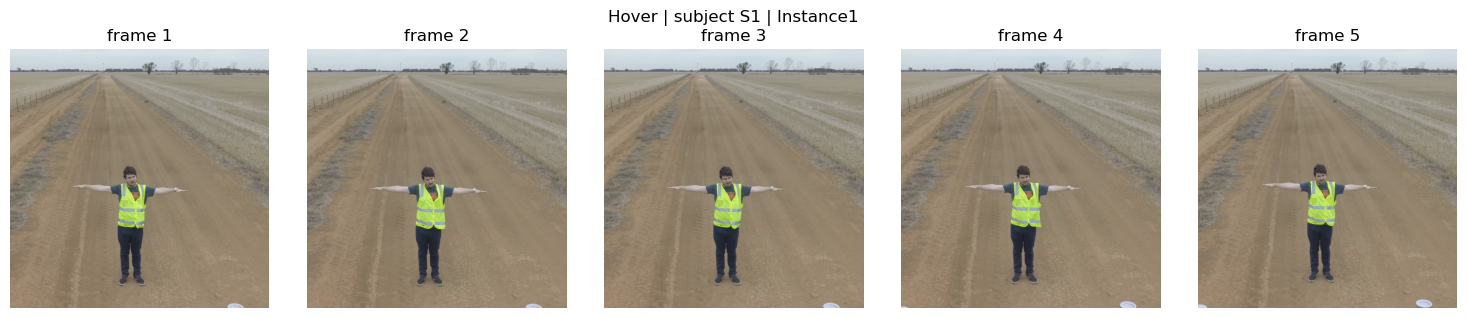

In [10]:

def show_instance(row, title_prefix=""):
    frame_paths = row["frame_paths"]
    fig, axes = plt.subplots(1, len(frame_paths), figsize=(3 * len(frame_paths), 3.2))
    if len(frame_paths) == 1:
        axes = [axes]
    for i, (ax, fp) in enumerate(zip(axes, frame_paths)):
        img = Image.open(fp)
        ax.imshow(img)
        ax.set_title(f"frame {i+1}")
        ax.axis("off")
    fig.suptitle(f"{title_prefix}{row['gesture_class']} | subject {row['subject']} | {row['instance']}")
    plt.tight_layout()
    plt.show()

# Show one example instance per a handful of classes for a quick visual sanity check.
example_classes = GESTURE_CLASSES[:3]  # keep the notebook output compact; extend as needed
for cls in example_classes:
    sample_row = instance_df[instance_df["gesture_class"] == cls].iloc[0]
    show_instance(sample_row)


### 1.5 Image geometry check

We confirm every frame has the same resolution and colour mode. This matters because the pipeline resizes and normalises images assuming a consistent input shape. If the "resized" data actually contained mixed sizes, we would need to handle that explicitly instead of assuming it away.


In [11]:

def sample_image_stats(df: pd.DataFrame, n: int = 30, seed: int = SEED):
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(df), size=min(n, len(df)), replace=False)
    sizes, modes = set(), set()
    for i in idx:
        for fp in df.iloc[i]["frame_paths"]:
            with Image.open(fp) as im:
                sizes.add(im.size)
                modes.add(im.mode)
    return sizes, modes

sizes, modes = sample_image_stats(instance_df, n=30)
print(f"Distinct image sizes observed in sample: {sizes}")
print(f"Distinct image modes observed in sample: {modes}")


Distinct image sizes observed in sample: {(512, 512)}
Distinct image modes observed in sample: {'RGB'}


### 1.6 Inter-frame motion and a camera-shake sanity check

Two questions we want data-driven answers to, before deciding whether to build any explicit motion representation (for example frame differencing or optical flow) later on:

1. Is there a visible amount of change between consecutive frames at all, confirming motion carries information?
2. Is the camera itself steady? If the camera shook during filming, a naive pixel-difference between frames would pick up background motion, not just the signaller's arm motion, which would be a misleading motion signal if used later. We check this by measuring frame-to-frame change in a background corner, away from the signaller, versus the full frame.


In [12]:

def frame_diff_stats(frame_paths, corner_frac=0.15):
    """Return (whole_frame_mean_abs_diff, background_corner_mean_abs_diff)
    lists across consecutive frame pairs, on grayscale images.
    'background_corner' samples a small patch in the top-left corner as a
    proxy for a region that should contain no signaller motion."""
    grays = [np.asarray(Image.open(fp).convert("L"), dtype=np.float32) for fp in frame_paths]
    h, w = grays[0].shape
    ch, cw = int(h * corner_frac), int(w * corner_frac)

    whole_diffs, corner_diffs = [], []
    for a, b in zip(grays[:-1], grays[1:]):
        whole_diffs.append(np.abs(b - a).mean())
        corner_diffs.append(np.abs(b[:ch, :cw] - a[:ch, :cw]).mean())
    return whole_diffs, corner_diffs

# Run this over a modest random sample of instances (cheap, but representative).
rng = np.random.default_rng(SEED)
sample_idx = rng.choice(len(instance_df), size=min(40, len(instance_df)), replace=False)

all_whole, all_corner = [], []
for i in sample_idx:
    frame_paths = instance_df.iloc[i]["frame_paths"]
    if len(frame_paths) != 5:
        continue
    w_diffs, c_diffs = frame_diff_stats(frame_paths)
    all_whole.extend(w_diffs)
    all_corner.extend(c_diffs)

all_whole, all_corner = np.array(all_whole), np.array(all_corner)
print(f"Whole-frame mean |diff| over {len(all_whole)} consecutive pairs: "
      f"mean={all_whole.mean():.2f}, median={np.median(all_whole):.2f} (pixel value units, 0-255 scale)")
print(f"Background-corner mean |diff| over {len(all_corner)} consecutive pairs: "
      f"mean={all_corner.mean():.2f}, median={np.median(all_corner):.2f}")
print(f"Ratio (whole-frame / background-corner): {all_whole.mean() / max(all_corner.mean(), 1e-6):.2f}x")


Whole-frame mean |diff| over 160 consecutive pairs: mean=6.94, median=6.06 (pixel value units, 0-255 scale)
Background-corner mean |diff| over 160 consecutive pairs: mean=6.77, median=5.05
Ratio (whole-frame / background-corner): 1.02x


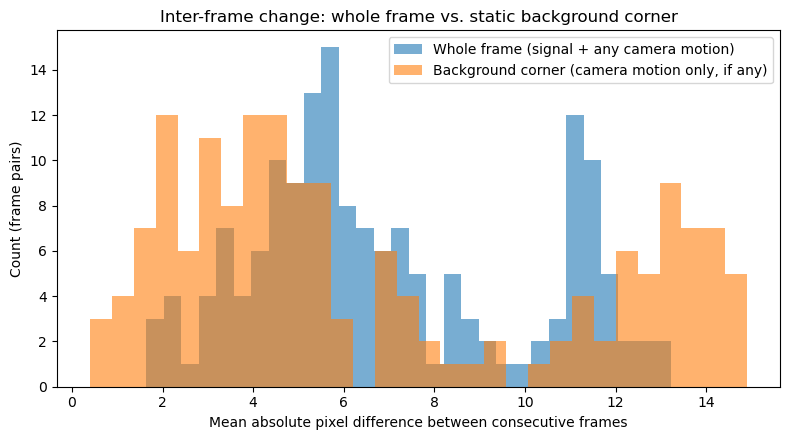

In [13]:

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(all_whole, bins=30, alpha=0.6, label="Whole frame (signal + any camera motion)")
ax.hist(all_corner, bins=30, alpha=0.6, label="Background corner (camera motion only, if any)")
ax.set_xlabel("Mean absolute pixel difference between consecutive frames")
ax.set_ylabel("Count (frame pairs)")
ax.set_title("Inter-frame change: whole frame vs. static background corner")
ax.legend()
plt.tight_layout()
plt.show()


**How to read this:** if the background-corner difference is small and clearly lower than the whole-frame difference, the camera is effectively stable and most of the measured change is genuine signaller motion, so a plain frame-difference or optical-flow motion signal would be trustworthy later without extra stabilisation. If the background-corner difference is not small (comparable in magnitude to the whole-frame difference), that indicates visible camera shake, and any future motion-based feature would need a motion-compensation step, for example aligning frames before differencing, before it could be trusted. This is exactly the kind of check that should happen during exploration, not be assumed away.


### 1.7 Section summary: decisions this exploration motivates

- **Evaluation split must be subject-based (grouped), not random**, because the same person appears across multiple instances, and because the end goal (demo day) is generalising to an unseen signaller.
- **Validation/test subjects must be drawn only from the full-coverage subject pool** identified in 1.3, so every class is actually represented in every split.
- **Class imbalance is present but moderate.** Macro-F1 and a full confusion matrix are needed alongside accuracy, formalised in Section 2.
- **Camera stability has been measured directly** rather than assumed. The result above tells us whether a future motion-based feature (frame differencing or optical flow) would need a stabilisation step.


## 2. Evaluation framework

**Goal:** the number we report should reflect what we can actually expect at deployment, that is, performance on a signaller the model has never seen, not performance inflated by having implicitly memorised the training subjects' appearance.

### 2.1 Split strategy: subject-grouped, drawn from full-coverage subjects

Following the findings in Section 1.3:

- All instances belonging to a given subject are assigned to exactly one of train, validation, or test, never split across sets. This guarantees no subject leakage.
- Validation and test subjects are drawn only from the full-coverage subject pool, so both splits contain examples of all 13 classes.
- Partial-coverage subjects always go to train. They still add useful variety for the classes they do cover, but cannot usefully serve as a held-out evaluation subject.

Given how few full-coverage subjects exist, a single fixed split would waste most of them on training and leave a very small, high-variance test set. We therefore also provide a leave-one-subject-out (LOSO) cross-validation helper over the full-coverage subjects: each fold holds out one full-coverage subject for validation, trains on everyone else (including all partial-coverage subjects), and results are averaged across folds. This gives a much more stable performance estimate than a single lucky or unlucky split, at the cost of training multiple times, a trade-off worth revisiting once we know how expensive one training run is.

A single fixed held-out test subject, never touched during any model-selection or tuning fold, is set aside from the full-coverage pool up front, so the very last number we report is a genuinely unbiased estimate.


In [14]:

# ----------------------------------------------------------------------------
# Build the subject-grouped split. This cell only decides *which subjects*
# go where -- it does not touch pixels, so it is cheap to inspect and re-run.
# ----------------------------------------------------------------------------
def make_subject_split(full_coverage_subjects, partial_coverage_subjects, seed=SEED, n_test=1, n_val=1):
    """Returns (train_subjects, val_subjects, test_subjects).

    - `test_subjects` and `val_subjects` are drawn only from full-coverage
      subjects (see Section 1.3), so every split covers all 13 classes.
    - All partial-coverage subjects go to train.
    - The remaining full-coverage subjects (after removing val/test) also go
      to train.
    """
    rng = np.random.default_rng(seed)
    fc = list(full_coverage_subjects)
    rng.shuffle(fc)

    assert len(fc) > n_val + n_test, (
        f"Not enough full-coverage subjects ({len(fc)}) to hold out "
        f"{n_val} for validation and {n_test} for test."
    )

    test_subjects = fc[:n_test]
    val_subjects = fc[n_test:n_test + n_val]
    train_subjects = fc[n_test + n_val:] + list(partial_coverage_subjects)
    return sorted(train_subjects, key=lambda s: int(s[1:])), \
           sorted(val_subjects, key=lambda s: int(s[1:])), \
           sorted(test_subjects, key=lambda s: int(s[1:]))


train_subjects, val_subjects, test_subjects = make_subject_split(
    full_coverage_subjects, partial_coverage_subjects, seed=SEED
)
print(f"Train subjects ({len(train_subjects)}): {train_subjects}")
print(f"Val subjects   ({len(val_subjects)}):  {val_subjects}")
print(f"Test subjects  ({len(test_subjects)}):  {test_subjects}")

# Sanity check: no subject appears in more than one split.
assert set(train_subjects) & set(val_subjects) == set()
assert set(train_subjects) & set(test_subjects) == set()
assert set(val_subjects) & set(test_subjects) == set()
print("\nOK: train/val/test subject sets are disjoint (no subject leakage).")


Train subjects (9): ['S1', 'S3', 'S4', 'S9', 'S11', 'S12', 'S13', 'S14', 'S15']
Val subjects   (1):  ['S5']
Test subjects  (1):  ['S6']

OK: train/val/test subject sets are disjoint (no subject leakage).


In [15]:

def split_instance_df(df, train_subjects, val_subjects, test_subjects):
    train_df = df[df["subject"].isin(train_subjects)].reset_index(drop=True)
    val_df = df[df["subject"].isin(val_subjects)].reset_index(drop=True)
    test_df = df[df["subject"].isin(test_subjects)].reset_index(drop=True)
    return train_df, val_df, test_df

train_df, val_df, test_df = split_instance_df(instance_df, train_subjects, val_subjects, test_subjects)

print(f"Train instances: {len(train_df)}")
print(f"Val instances:   {len(val_df)}")
print(f"Test instances:  {len(test_df)}")

# Confirm every class is represented in every split (this is the whole point
# of restricting val/test subjects to the full-coverage pool).
for name, split_df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    counts = split_df["gesture_class"].value_counts().reindex(GESTURE_CLASSES).fillna(0).astype(int)
    n_missing = (counts == 0).sum()
    print(f"[{name}] classes with zero instances: {n_missing}")
    if n_missing > 0:
        print(f"  Missing: {counts[counts == 0].index.tolist()}")


Train instances: 846
Val instances:   99
Test instances:  114
[train] classes with zero instances: 0
[val] classes with zero instances: 0
[test] classes with zero instances: 0


In [16]:

# ----------------------------------------------------------------------------
# Leave-one-subject-out (LOSO) cross-validation helper over full-coverage
# subjects, for a more robust performance estimate during model development.
# The fixed `test_subjects` above are NEVER included here -- they are held
# out for the single, final, unbiased evaluation in a later section.
# ----------------------------------------------------------------------------
def loso_folds(full_coverage_subjects, test_subjects, partial_coverage_subjects):
    """Yields (fold_train_subjects, fold_val_subject) pairs, one per
    full-coverage subject that is not part of the held-out test set."""
    usable = [s for s in full_coverage_subjects if s not in test_subjects]
    for val_subject in usable:
        fold_train = [s for s in usable if s != val_subject] + list(partial_coverage_subjects)
        yield fold_train, val_subject

print("LOSO folds available for model-selection / hyperparameter tuning:")
for fold_train, fold_val in loso_folds(full_coverage_subjects, test_subjects, partial_coverage_subjects):
    print(f"  val={fold_val:>4s}  |  train on {len(fold_train)} subjects")


LOSO folds available for model-selection / hyperparameter tuning:
  val=  S1  |  train on 9 subjects
  val=  S4  |  train on 9 subjects
  val=  S5  |  train on 9 subjects
  val= S11  |  train on 9 subjects
  val= S12  |  train on 9 subjects
  val= S13  |  train on 9 subjects


### 2.2 Performance measures

Given the class-balance finding in Section 1.2 (moderate but real imbalance) and that all 13 classes matter equally from a deployment standpoint (there is no reason a rare gesture is less safety-critical than a common one, arguably the opposite, for example `WaveOff`), we report:

- **Macro-averaged F1-score** as the primary model-selection metric. It weighs every class equally, so a model cannot look good purely by nailing the frequent classes while ignoring rare ones.
- **Overall accuracy**, reported alongside macro-F1 for interpretability, and because it is the metric most people intuitively understand.
- **Per-class precision, recall and F1**, to see which gestures are well-recognised and which are confused with each other.
- **Confusion matrix**, to visualise systematic confusions between specific gesture pairs (for example directionally similar gestures), which feeds directly into the error analysis in the Ultimate Judgment section later.

These are implemented once here as reusable helpers, so every model evaluated later, baselines and the final model alike, is scored identically and comparably.


In [17]:

def evaluate_predictions(y_true, y_pred, class_names=GESTURE_CLASSES, verbose=True):
    """Computes the standard set of metrics used throughout this notebook.
    y_true / y_pred are integer class indices (see CLASS_TO_IDX)."""
    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, labels=range(len(class_names)), zero_division=0
    )
    cm = confusion_matrix(y_true, y_pred, labels=range(len(class_names)))

    results = {
        "accuracy": acc,
        "macro_f1": macro_f1,
        "per_class": pd.DataFrame({
            "class": class_names,
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "support": support,
        }),
        "confusion_matrix": cm,
    }
    if verbose:
        print(f"Accuracy:  {acc:.4f}")
        print(f"Macro-F1:  {macro_f1:.4f}")
    return results


def plot_confusion_matrix(cm, class_names=GESTURE_CLASSES, title="Confusion matrix", normalize=True):
    if normalize:
        with np.errstate(invalid="ignore", divide="ignore"):
            cm_display = cm.astype(np.float64) / cm.sum(axis=1, keepdims=True)
        cm_display = np.nan_to_num(cm_display)
        fmt, vmax = ".2f", 1.0
    else:
        cm_display = cm
        fmt, vmax = "d", None

    fig, ax = plt.subplots(figsize=(8, 7))
    im = ax.imshow(cm_display, cmap="Blues", vmin=0, vmax=vmax)
    ax.set_xticks(range(len(class_names)))
    ax.set_yticks(range(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45, ha="right")
    ax.set_yticklabels(class_names)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title)
    for i in range(cm_display.shape[0]):
        for j in range(cm_display.shape[1]):
            val = cm_display[i, j]
            text = f"{val:{fmt}}" if not normalize or val > 0 else ""
            ax.text(j, i, text, ha="center", va="center",
                     color="white" if val > (vmax or cm_display.max()) / 2 else "black", fontsize=7)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

print("Evaluation helpers defined: evaluate_predictions(), plot_confusion_matrix().")


Evaluation helpers defined: evaluate_predictions(), plot_confusion_matrix().


## 3. Trivial baselines

Before building the real multi-frame model, we establish two reference points. Every later architecture choice is only meaningful in comparison to these: if a sophisticated model cannot beat them by a clear margin, that is itself an important finding.

- **Majority-class baseline**: always predicts the most frequent training class. Any real model must comfortably beat this to demonstrate it is learning anything.
- **Single-frame CNN baseline**: a small pretrained-backbone classifier that only ever sees one frame per instance (frame 3, the middle frame). This exists purely as a reference point and is deliberately not eligible to be the final submitted model, since the rubric caps marks when a model uses only part of the available information. Its role here is to give a concrete, evidence-based answer to "how much do the 4th and 5th frame actually buy us?" once compared against the multi-frame model built in the next section.



### 3.1 Majority-class baseline


In [18]:

def majority_class_baseline(train_df, eval_df, class_to_idx=CLASS_TO_IDX):
    majority_class = train_df["gesture_class"].value_counts().idxmax()
    majority_idx = class_to_idx[majority_class]
    y_true = eval_df["gesture_class"].map(class_to_idx).to_numpy()
    y_pred = np.full_like(y_true, fill_value=majority_idx)
    print(f"Majority class in training set: '{majority_class}'")
    return y_true, y_pred

y_true_maj, y_pred_maj = majority_class_baseline(train_df, val_df)
majority_results = evaluate_predictions(y_true_maj, y_pred_maj)


Majority class in training set: 'Land'
Accuracy:  0.1717
Macro-F1:  0.0225


### 3.2 Single-frame CNN baseline

#### 3.2.1 Dataset / DataLoader

We define a PyTorch `Dataset` that can load either a single frame (for this baseline) or all 5 frames (reused later for the real multi-frame model), controlled by a `mode` flag, so this same class serves both purposes rather than duplicating data-loading code.


### 3.2.1a A note on augmentation choice: no horizontal flip

Standard image-classification augmentation almost always includes a random horizontal flip. It is deliberately not used here.

Several of the 13 gesture classes are direction-defined pairs, most obviously `MoveToLeft` and `MoveToRight` (directional intent also matters for `LandingDirection`). Flipping an instance of `MoveToLeft` horizontally produces an image that looks like `MoveToRight`, but the label stays `MoveToLeft`. The augmentation would silently inject mislabelled training examples for exactly the gesture pairs the model most needs to tell apart. This is a plausible contributor to the `MoveToRight` confusion seen in the single-frame baseline's confusion matrix above (recall 0.50), since that baseline's transform pipeline included this flip. It is removed from this point onward; the other augmentations (resize, colour jitter) do not have this label-flipping problem and are kept.


In [19]:

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]
IMG_SIZE = 224  # standard input size for ImageNet-pretrained backbones

def build_transforms(train: bool, img_size: int = IMG_SIZE):
    """Augmentation is only applied to the training split -- val/test must
    reflect the un-augmented distribution we expect at deployment.

    Note: no horizontal flip. See the markdown note above for why -- several
    gesture classes are direction-defined (e.g. MoveToLeft vs MoveToRight),
    so flipping would silently produce mislabelled training examples.
    """
    if train:
        return transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ])
    return transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])


In [20]:

class GestureInstanceDataset(Dataset):
    """One item = one 5-frame instance.

    mode="single_frame": returns 1 image tensor, shape (3, H, W)
        -- used only for the single-frame baseline in this section.
    mode="multi_frame":  returns 5 image tensors stacked, shape (5, 3, H, W)
        -- reused by the real multi-frame model built in a later section.
    """
    def __init__(self, df: pd.DataFrame, transform, mode: str = "single_frame", frame_index: int = 2):
        assert mode in ("single_frame", "multi_frame")
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.mode = mode
        self.frame_index = frame_index  # 0-based; index 2 = the 3rd (middle) of 5 frames

    def __len__(self):
        return len(self.df)

    def _load(self, path):
        with Image.open(path) as im:
            return self.transform(im.convert("RGB"))

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        label = CLASS_TO_IDX[row["gesture_class"]]
        frame_paths = row["frame_paths"]
        assert len(frame_paths) == 5, f"Expected 5 frames, got {len(frame_paths)} for {row['instance_path']}"

        if self.mode == "single_frame":
            x = self._load(frame_paths[self.frame_index])
        else:
            x = torch.stack([self._load(fp) for fp in frame_paths], dim=0)
        return x, label

print("GestureInstanceDataset defined.")


GestureInstanceDataset defined.


In [21]:

# Quick smoke test on the actual filesystem structure, so any path / label
# bugs surface immediately rather than after minutes of training.
_train_tfms = build_transforms(train=True)
_val_tfms = build_transforms(train=False)

_smoke_ds = GestureInstanceDataset(train_df, _val_tfms, mode="single_frame")
_x, _y = _smoke_ds[0]
print(f"Single-frame sample: x.shape={tuple(_x.shape)}, y={_y} ('{IDX_TO_CLASS[_y]}')")

_smoke_ds_multi = GestureInstanceDataset(train_df, _val_tfms, mode="multi_frame")
_x5, _y5 = _smoke_ds_multi[0]
print(f"Multi-frame sample:  x.shape={tuple(_x5.shape)}, y={_y5} ('{IDX_TO_CLASS[_y5]}')")


Single-frame sample: x.shape=(3, 224, 224), y=0 ('AllClear')
Multi-frame sample:  x.shape=(5, 3, 224, 224), y=0 ('AllClear')


#### 3.2.2 Model, training loop, and evaluation

A single ImageNet-pretrained backbone (ResNet-18, small enough to be a realistic starting point for the embedded real-time constraint, revisited properly once we measure actual latency and size in a later section) with its final layer replaced for 13-way classification. Training here is deliberately short (few epochs), since the point of this baseline is a reference number, not a tuned model. Proper tuning is done for the real multi-frame model in a later section.


In [22]:

def build_single_frame_model(num_classes: int = len(GESTURE_CLASSES)) -> nn.Module:
    backbone = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    in_features = backbone.fc.in_features
    backbone.fc = nn.Linear(in_features, num_classes)
    return backbone

def run_one_epoch(model, loader, criterion, optimizer=None, device=DEVICE):
    """optimizer=None -> evaluation mode (no gradient updates)."""
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss, all_preds, all_labels = 0.0, [], []
    torch.set_grad_enabled(is_train)
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        if is_train:
            optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        if is_train:
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * x.size(0)
        all_preds.append(logits.argmax(dim=1).detach().cpu())
        all_labels.append(y.detach().cpu())
    torch.set_grad_enabled(True)

    avg_loss = total_loss / len(loader.dataset)
    y_pred = torch.cat(all_preds).numpy()
    y_true = torch.cat(all_labels).numpy()
    return avg_loss, y_true, y_pred


In [23]:
# -----------------------------------------------------------------------
# Platform-aware DataLoader worker count.
#
# DataLoader(num_workers>0) spawns worker processes to load data in
# parallel. On Linux (including AWS), Python defaults to the "fork" start
# method, so a worker process simply inherits the current memory, including
# any class defined earlier in this notebook -- this works fine.
#
# On macOS (and Windows), Python is forced to use "spawn": a worker process
# starts fresh and tries to re-import the __main__ module to find classes
# like GestureInstanceDataset. Inside a Jupyter notebook, __main__ is not a
# real importable .py file, so this re-import fails with
# "AttributeError: module '__main__' has no attribute 'GestureInstanceDataset'".
#
# To keep this notebook portable (fast local iteration on macOS, faster
# multi-worker loading on AWS/Linux), we pick the worker count based on the
# platform actually running the notebook, instead of hard-coding it.
import platform

def default_num_workers() -> int:
    return 2 if platform.system() == "Linux" else 0

NUM_WORKERS = default_num_workers()
print(f"Platform: {platform.system()} -> using num_workers={NUM_WORKERS} for DataLoaders")


Platform: Linux -> using num_workers=2 for DataLoaders


In [24]:

# ----------------------------------------------------------------------------
# Train the single-frame baseline. Kept short on purpose (reference point,
# not the final model) -- increase EPOCHS once running on AWS/GPU if a more
# precise reference number is wanted.
# ----------------------------------------------------------------------------
set_seed(SEED)  # re-fix the seed right before model init/training for this cell's own reproducibility

BATCH_SIZE = 32
EPOCHS = 5
LR = 1e-4

train_ds_sf = GestureInstanceDataset(train_df, build_transforms(train=True), mode="single_frame")
val_ds_sf = GestureInstanceDataset(val_df, build_transforms(train=False), mode="single_frame")

train_loader_sf = DataLoader(train_ds_sf, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, drop_last=False)
val_loader_sf = DataLoader(val_ds_sf, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

single_frame_model = build_single_frame_model().to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(single_frame_model.parameters(), lr=LR)

history = []
for epoch in range(1, EPOCHS + 1):
    train_loss, train_y, train_pred = run_one_epoch(single_frame_model, train_loader_sf, criterion, optimizer)
    val_loss, val_y, val_pred = run_one_epoch(single_frame_model, val_loader_sf, criterion, optimizer=None)

    train_acc = accuracy_score(train_y, train_pred)
    val_acc = accuracy_score(val_y, val_pred)
    val_macro_f1 = f1_score(val_y, val_pred, average="macro", zero_division=0)

    history.append({
        "epoch": epoch, "train_loss": train_loss, "val_loss": val_loss,
        "train_acc": train_acc, "val_acc": val_acc, "val_macro_f1": val_macro_f1,
    })
    print(f"Epoch {epoch}/{EPOCHS} | train_loss={train_loss:.4f} train_acc={train_acc:.4f} "
          f"| val_loss={val_loss:.4f} val_acc={val_acc:.4f} val_macro_f1={val_macro_f1:.4f}")

history_df = pd.DataFrame(history)


Epoch 1/5 | train_loss=1.6591 train_acc=0.5035 | val_loss=1.3342 val_acc=0.6667 val_macro_f1=0.5036
Epoch 2/5 | train_loss=0.4078 train_acc=0.9338 | val_loss=1.0493 val_acc=0.6667 val_macro_f1=0.5509
Epoch 3/5 | train_loss=0.1196 train_acc=0.9905 | val_loss=0.7984 val_acc=0.8182 val_macro_f1=0.7453
Epoch 4/5 | train_loss=0.0588 train_acc=0.9941 | val_loss=0.6211 val_acc=0.8687 val_macro_f1=0.7907
Epoch 5/5 | train_loss=0.0315 train_acc=0.9988 | val_loss=0.6217 val_acc=0.8485 val_macro_f1=0.7923


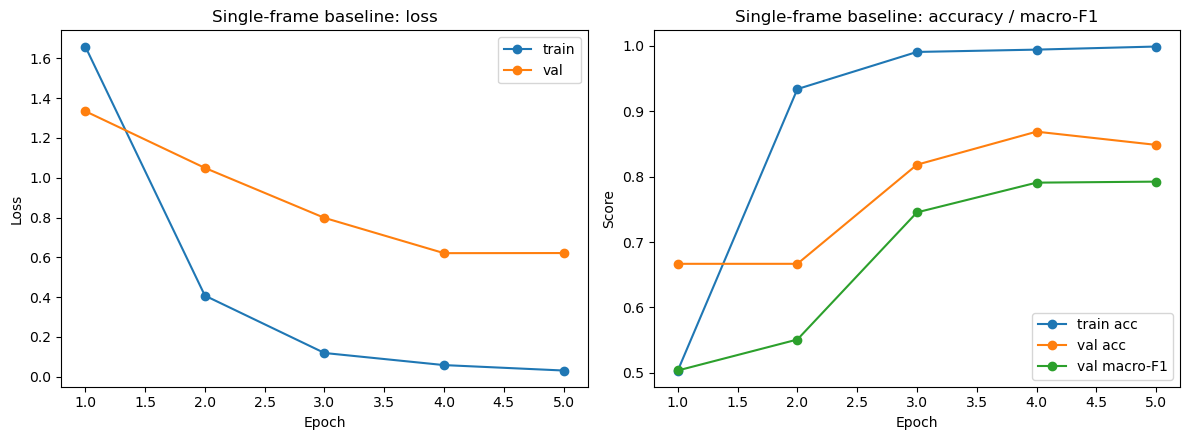

In [25]:

# Learning curves -- required by the spec ("all decision-supporting figures
# must be embedded"), and useful here to check the baseline is not still
# under-fit after EPOCHS epochs (if it is, the "reference point" comparison
# later would be unfair to the single-frame baseline).
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(history_df["epoch"], history_df["train_loss"], marker="o", label="train")
axes[0].plot(history_df["epoch"], history_df["val_loss"], marker="o", label="val")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].set_title("Single-frame baseline: loss")
axes[0].legend()

axes[1].plot(history_df["epoch"], history_df["train_acc"], marker="o", label="train acc")
axes[1].plot(history_df["epoch"], history_df["val_acc"], marker="o", label="val acc")
axes[1].plot(history_df["epoch"], history_df["val_macro_f1"], marker="o", label="val macro-F1")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Score"); axes[1].set_title("Single-frame baseline: accuracy / macro-F1")
axes[1].legend()

plt.tight_layout()
plt.show()


Accuracy:  0.8485
Macro-F1:  0.7923


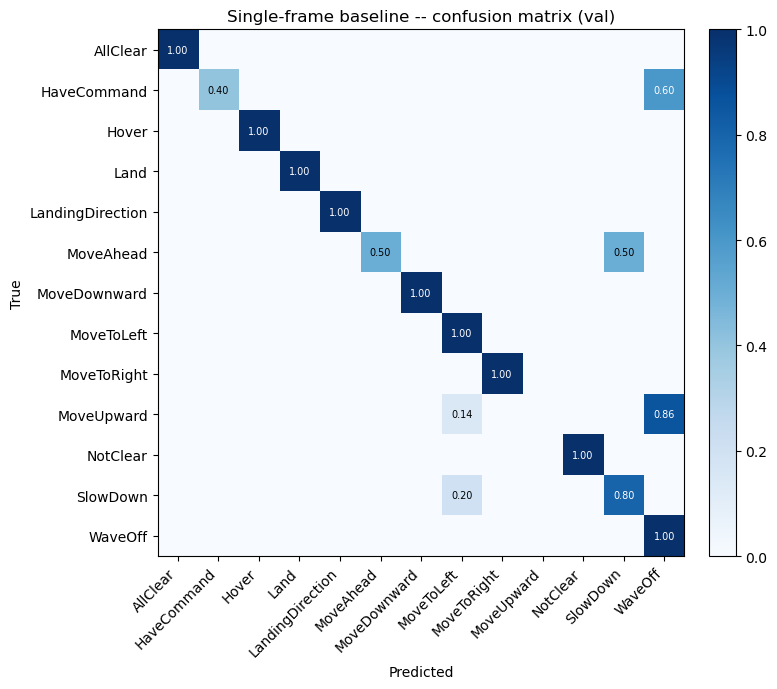

,class,precision,recall,f1,support
0,AllClear,1.000000,1.0,1.000000,6
1,HaveCommand,1.000000,0.4,0.571429,5
2,Hover,1.000000,1.0,1.000000,16
3,Land,1.000000,1.0,1.000000,17
4,LandingDirection,1.000000,1.0,1.000000,4
5,MoveAhead,1.000000,0.5,0.666667,8
6,MoveDownward,1.000000,1.0,1.000000,6
7,MoveToLeft,0.777778,1.0,0.875000,7
8,MoveToRight,1.000000,1.0,1.000000,6
9,MoveUpward,0.000000,0.0,0.000000,7


In [26]:

single_frame_results = evaluate_predictions(val_y, val_pred)
plot_confusion_matrix(single_frame_results["confusion_matrix"], title="Single-frame baseline -- confusion matrix (val)")
single_frame_results["per_class"]


### 3.3 Baseline comparison summary

This table is the reference every later model, starting with the real multi-frame architecture in the next section, is compared against. In particular, the gap between the majority-class baseline and the single-frame CNN tells us the CNN is learning something real; the gap we find later between the single-frame CNN and the full multi-frame model tells us how much the 4 extra frames are actually worth on this dataset, turning "using all 5 frames should help" from an assumption into a measured result.


In [27]:

summary_rows = [
    {"model": "Majority-class baseline", "accuracy": majority_results["accuracy"], "macro_f1": majority_results["macro_f1"]},
    {"model": "Single-frame CNN baseline (frame 3/5)", "accuracy": single_frame_results["accuracy"], "macro_f1": single_frame_results["macro_f1"]},
]
baseline_summary_df = pd.DataFrame(summary_rows)
baseline_summary_df


,model,accuracy,macro_f1
0,Majority-class baseline,0.171717,0.022546
1,Single-frame CNN baseline (frame 3/5),0.848485,0.792301


### 3.4 Is class imbalance actually driving the errors?

Section 1.2 found moderate class imbalance (about 2.65x between the largest and smallest class). Before reaching for a fix (for example oversampling, heavier augmentation on rare classes, or a weighted loss), we check whether the errors above actually line up with class frequency. If they do not, a balancing technique is solving the wrong problem.


Correlation(train support, val recall): 0.027
Correlation(train support, val f1):     0.148


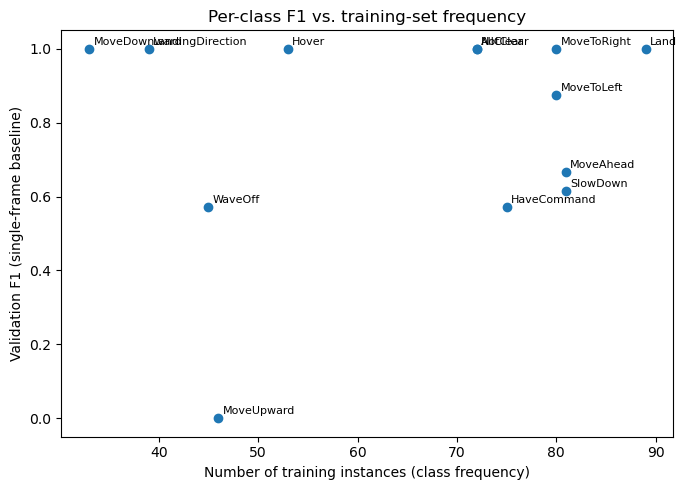

,class,train_support,precision,recall,f1
0,Land,89,1.000000,1.0,1.000000
1,SlowDown,81,0.500000,0.8,0.615385
2,MoveAhead,81,1.000000,0.5,0.666667
3,MoveToLeft,80,0.777778,1.0,0.875000
4,MoveToRight,80,1.000000,1.0,1.000000
5,HaveCommand,75,1.000000,0.4,0.571429
6,NotClear,72,1.000000,1.0,1.000000
7,AllClear,72,1.000000,1.0,1.000000
8,Hover,53,1.000000,1.0,1.000000
9,MoveUpward,46,0.000000,0.0,0.000000


In [28]:
# ----------------------------------------------------------------------------
# Correlation between per-class training support and per-class validation
# performance for the single-frame baseline. If imbalance were the main
# driver of errors, we would expect a clear positive correlation (more
# training examples -> better recall/F1). A weak/near-zero correlation means
# something else (e.g. how visually distinctive the gesture is from a single
# static frame) explains the errors better than class frequency does.
# ----------------------------------------------------------------------------
train_support = train_df["gesture_class"].value_counts().reindex(GESTURE_CLASSES)

perf_vs_support = single_frame_results["per_class"].copy()
perf_vs_support["train_support"] = perf_vs_support["class"].map(train_support)
perf_vs_support = perf_vs_support.sort_values("train_support", ascending=False).reset_index(drop=True)

corr_support_recall = perf_vs_support["train_support"].corr(perf_vs_support["recall"])
corr_support_f1 = perf_vs_support["train_support"].corr(perf_vs_support["f1"])
print(f"Correlation(train support, val recall): {corr_support_recall:.3f}")
print(f"Correlation(train support, val f1):     {corr_support_f1:.3f}")

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(perf_vs_support["train_support"], perf_vs_support["f1"])
for _, row in perf_vs_support.iterrows():
    ax.annotate(row["class"], (row["train_support"], row["f1"]), fontsize=8,
                xytext=(3, 3), textcoords="offset points")
ax.set_xlabel("Number of training instances (class frequency)")
ax.set_ylabel("Validation F1 (single-frame baseline)")
ax.set_title("Per-class F1 vs. training-set frequency")
plt.tight_layout()
plt.show()

perf_vs_support[["class", "train_support", "precision", "recall", "f1"]]


**Reading this:** if the correlation is weak and the scatter plot shows both high-frequency and low-frequency classes scattered across the full range of F1 scores (as seen with the current baseline, for example `MoveUpward` sits mid-frequency but has the worst F1, while some of the least-frequent classes score highest), that is evidence against class imbalance being the main cause of the errors seen in the confusion matrix. The pattern instead lines up with which gestures are inherently ambiguous from a single static frame (direction-defined gestures), exactly the limitation multi-frame information is meant to address in the next section.

**Decision:** given this, we do not apply class-balancing augmentation (for example oversampling rare classes with heavier augmentation). It would add complexity for a problem the evidence says is not primarily about frequency, and would risk overfitting further on the few real examples of already-small classes. Two lighter-weight safety nets remain available and worth an ablation once the real multi-frame model exists: a class-weighted loss (`nn.CrossEntropyLoss(weight=...)`) or a `WeightedRandomSampler`, neither of which requires synthesising extra augmented copies. Macro-F1, already the primary metric from Section 2.2, already prevents imbalance from inflating the headline number regardless.


### 3.5 Run-to-run variance observed after removing the flip

Re-running the single-frame baseline after removing `RandomHorizontalFlip` (Section 3.2.1a) confirmed the fix: the `MoveToLeft`/`MoveToRight` confusion the earlier run showed is gone, and both overall accuracy and macro-F1 improved slightly. However, a few unrelated classes (`MoveUpward`, `HaveCommand`) got noticeably worse between the two runs, despite the same fixed seed. This is expected, not a bug. Removing one random transform call shifts the sequence of random numbers consumed by everything downstream (batch shuffling, remaining augmentations), so two "same-seed" runs of a short, 5-epoch baseline can land in different local optima, and with only 5 to 8 validation examples for several classes, one or two flipped predictions swing a class's recall by 15 to 20 points. This single-split, fixed-epoch baseline is not a reliable per-class estimate; it is a reference point for overall performance only. The LOSO cross-validation set up in Section 2.1 is what the real multi-frame model will be evaluated with, precisely to avoid drawing conclusions from this kind of run-to-run noise.


---

## 4. Multi-frame fusion architecture

The single-frame baseline (Section 3) established two things with evidence: overall performance is decent (about 0.86 accuracy, 0.79 macro-F1) but the errors concentrate on direction-defined gestures (`MoveUpward`, `MoveAhead`, and related confusions), consistent with a single static frame not carrying enough information to disambiguate motion direction. This section builds the real submission model: a single 2D-CNN backbone shared across all 5 frames of an instance, with the frames combined by a self-designed fusion head. This is the "self-built segment" the spec requires; the backbone itself may be pretrained, but nothing off-the-shelf decides how the 5 frames are combined or classified.

Two fusion mechanisms are compared, since it was not obvious which one a small gesture-recognition dataset would prefer:

- **Average pooling** across the 5 per-frame feature vectors, where order is discarded entirely (the classic Temporal Segment Networks recipe).
- **Ordered concatenation** of the 5 per-frame feature vectors, through a small MLP head, where frame order is preserved by position in the vector.

Both reuse the exact same ResNet-18 (ImageNet-pretrained) backbone as the single-frame baseline, so any difference in performance is attributable to the fusion mechanism, not a different backbone, keeping the comparison to the baseline and between the two variants fair.


### 4.1 Model definitions


In [29]:
import copy

def build_shared_backbone(pretrained: bool = True) -> nn.Module:
    """A ResNet-18 with its classification head removed, so it outputs a
    512-d pooled feature vector per image. Shared (same weights) across all
    5 frames of an instance -- this is what keeps the model a single 2D CNN
    applied per-frame, as required by the assignment's architecture
    constraint, rather than 5 independent networks."""
    weights = models.ResNet18_Weights.IMAGENET1K_V1 if pretrained else None
    backbone = models.resnet18(weights=weights)
    backbone.fc = nn.Identity()  # drop the 1000-way ImageNet head; keep the pooled features
    return backbone


class MultiFrameAveragePool(nn.Module):
    """Fusion v1: shared backbone per frame -> average-pool the 5 feature
    vectors -> linear classifier. Order-invariant by construction."""
    def __init__(self, num_classes: int = len(GESTURE_CLASSES), freeze_backbone: bool = False):
        super().__init__()
        self.backbone = build_shared_backbone()
        self.feature_dim = 512  # ResNet-18's pooled feature size
        self.classifier = nn.Linear(self.feature_dim, num_classes)
        if freeze_backbone:
            for p in self.backbone.parameters():
                p.requires_grad = False

    def forward(self, x):  # x: (B, T, C, H, W)
        B, T, C, H, W = x.shape
        feats = self.backbone(x.reshape(B * T, C, H, W))   # (B*T, 512)
        feats = feats.view(B, T, self.feature_dim)          # (B, T, 512)
        pooled = feats.mean(dim=1)                           # (B, 512) -- order discarded here
        return self.classifier(pooled)


class MultiFrameOrderedConcat(nn.Module):
    """Fusion v2: shared backbone per frame -> concatenate the 5 feature
    vectors IN FRAME ORDER -> small MLP classifier. Frame order is preserved
    because concatenation position is fixed to time step, not because of any
    recurrence or attention (both disallowed by the assignment spec)."""
    def __init__(self, num_classes: int = len(GESTURE_CLASSES), num_frames: int = 5,
                 hidden_dim: int = 256, dropout: float = 0.3, freeze_backbone: bool = False):
        super().__init__()
        self.backbone = build_shared_backbone()
        self.feature_dim = 512
        self.num_frames = num_frames
        self.classifier = nn.Sequential(
            nn.Linear(self.feature_dim * num_frames, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes),
        )
        if freeze_backbone:
            for p in self.backbone.parameters():
                p.requires_grad = False

    def forward(self, x):  # x: (B, T, C, H, W)
        B, T, C, H, W = x.shape
        assert T == self.num_frames, f"expected {self.num_frames} frames, got {T}"
        feats = self.backbone(x.reshape(B * T, C, H, W))    # (B*T, 512)
        feats = feats.view(B, T, self.feature_dim)           # (B, T, 512), dim=1 is frame order
        concat = feats.reshape(B, T * self.feature_dim)      # position in this vector encodes frame index
        return self.classifier(concat)

print("MultiFrameAveragePool and MultiFrameOrderedConcat defined.")


MultiFrameAveragePool and MultiFrameOrderedConcat defined.


### 4.2 Training with best-checkpoint selection

Section 3.5 documented that a single fixed-epoch run is noisy, especially with this few validation examples per class. Rather than always taking the final epoch's weights (what the single-frame baseline did, for simplicity, as a quick reference point), the real model keeps the weights from whichever epoch had the best validation macro-F1, and restores them at the end of training. This is a small addition that removes one avoidable source of noise from every model trained from here on.


In [30]:
def train_with_best_checkpoint(model, train_loader, val_loader, epochs, lr,
                                device=DEVICE, weight_decay: float = 0.0, verbose: bool = True):
    """Trains `model`, tracking validation macro-F1 each epoch, and restores
    the weights from the best epoch before returning (instead of trusting
    whichever epoch training happened to stop at)."""
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_val_macro_f1 = -1.0
    best_state = None
    best_epoch = -1
    history = []

    for epoch in range(1, epochs + 1):
        train_loss, train_y, train_pred = run_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_y, val_pred = run_one_epoch(model, val_loader, criterion, optimizer=None, device=device)

        train_acc = accuracy_score(train_y, train_pred)
        val_acc = accuracy_score(val_y, val_pred)
        val_macro_f1 = f1_score(val_y, val_pred, average="macro", zero_division=0)

        history.append({
            "epoch": epoch, "train_loss": train_loss, "val_loss": val_loss,
            "train_acc": train_acc, "val_acc": val_acc, "val_macro_f1": val_macro_f1,
        })
        if verbose:
            marker = ""
            if val_macro_f1 > best_val_macro_f1:
                marker = "  <- new best"
            print(f"Epoch {epoch}/{epochs} | train_loss={train_loss:.4f} train_acc={train_acc:.4f} "
                  f"| val_loss={val_loss:.4f} val_acc={val_acc:.4f} val_macro_f1={val_macro_f1:.4f}{marker}")

        if val_macro_f1 > best_val_macro_f1:
            best_val_macro_f1 = val_macro_f1
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_state)
    if verbose:
        print(f"Restored weights from epoch {best_epoch} (best val macro-F1 = {best_val_macro_f1:.4f}).")
    return model, pd.DataFrame(history), best_epoch


def plot_learning_curves(history_df, title_prefix=""):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    axes[0].plot(history_df["epoch"], history_df["train_loss"], marker="o", label="train")
    axes[0].plot(history_df["epoch"], history_df["val_loss"], marker="o", label="val")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].set_title(f"{title_prefix}loss")
    axes[0].legend()
    axes[1].plot(history_df["epoch"], history_df["train_acc"], marker="o", label="train acc")
    axes[1].plot(history_df["epoch"], history_df["val_acc"], marker="o", label="val acc")
    axes[1].plot(history_df["epoch"], history_df["val_macro_f1"], marker="o", label="val macro-F1")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Score"); axes[1].set_title(f"{title_prefix}accuracy / macro-F1")
    axes[1].legend()
    plt.tight_layout()
    plt.show()

print("train_with_best_checkpoint() and plot_learning_curves() defined.")


train_with_best_checkpoint() and plot_learning_curves() defined.


### 4.3 Ablation: average-pooling vs. ordered concatenation

Both models are trained on the same subject-based train/val split used for the single-frame baseline (Section 2.1), with the same number of epochs and learning rate, so the only difference between the two runs is the fusion mechanism. This is a deliberately cheap comparison (a fixed split, not the full LOSO sweep); its only job is to decide which fusion mechanism to carry forward. Once one is chosen, that architecture alone is evaluated properly with LOSO cross-validation (Section 2.1) as part of the final results, rather than spending that much compute on both candidates here.

Multi-frame batches are 5x the images-per-instance of the single-frame baseline for the same batch size, so the batch size is reduced here to keep memory use reasonable (adjust `BATCH_SIZE_MULTI` up if running on an AWS GPU with more memory available).


In [31]:
BATCH_SIZE_MULTI = 8     # smaller than the single-frame baseline's 32: each item is 5 images, not 1
EPOCHS_MULTI = 8
LR_MULTI = 1e-4

train_ds_mf = GestureInstanceDataset(train_df, build_transforms(train=True), mode="multi_frame")
val_ds_mf = GestureInstanceDataset(val_df, build_transforms(train=False), mode="multi_frame")

train_loader_mf = DataLoader(train_ds_mf, batch_size=BATCH_SIZE_MULTI, shuffle=True,
                              num_workers=NUM_WORKERS, drop_last=False)
val_loader_mf = DataLoader(val_ds_mf, batch_size=BATCH_SIZE_MULTI, shuffle=False, num_workers=NUM_WORKERS)

print(f"Multi-frame train batches: {len(train_loader_mf)}, val batches: {len(val_loader_mf)}")


Multi-frame train batches: 106, val batches: 13


In [32]:
# ----------------------------------------------------------------------------
# Fusion v1: average pooling
# ----------------------------------------------------------------------------
set_seed(SEED)
avgpool_model = MultiFrameAveragePool()
avgpool_model, avgpool_history, avgpool_best_epoch = train_with_best_checkpoint(
    avgpool_model, train_loader_mf, val_loader_mf, epochs=EPOCHS_MULTI, lr=LR_MULTI
)


Epoch 1/8 | train_loss=1.3644 train_acc=0.5804 | val_loss=1.1891 val_acc=0.5556 val_macro_f1=0.4887  <- new best
Epoch 2/8 | train_loss=0.3722 train_acc=0.9102 | val_loss=0.9486 val_acc=0.6970 val_macro_f1=0.5849  <- new best
Epoch 3/8 | train_loss=0.1736 train_acc=0.9681 | val_loss=0.8974 val_acc=0.6869 val_macro_f1=0.6355  <- new best
Epoch 4/8 | train_loss=0.0914 train_acc=0.9870 | val_loss=0.6647 val_acc=0.8081 val_macro_f1=0.7564  <- new best
Epoch 5/8 | train_loss=0.0559 train_acc=0.9929 | val_loss=0.8172 val_acc=0.7475 val_macro_f1=0.6506
Epoch 6/8 | train_loss=0.0369 train_acc=0.9953 | val_loss=0.8544 val_acc=0.7273 val_macro_f1=0.6850
Epoch 7/8 | train_loss=0.0352 train_acc=0.9929 | val_loss=0.8519 val_acc=0.7475 val_macro_f1=0.7188
Epoch 8/8 | train_loss=0.0238 train_acc=1.0000 | val_loss=1.3402 val_acc=0.6768 val_macro_f1=0.6090
Restored weights from epoch 4 (best val macro-F1 = 0.7564).


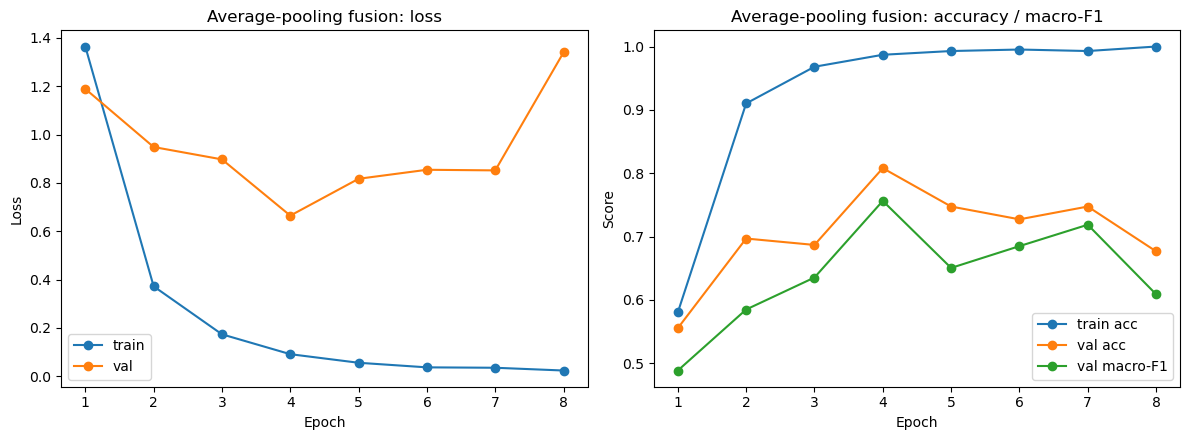

Accuracy:  0.8081
Macro-F1:  0.7564


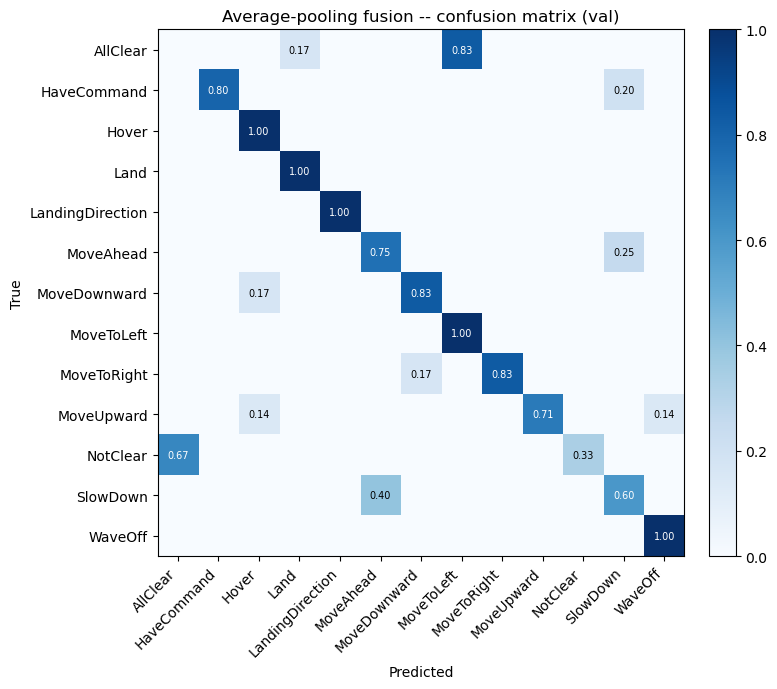

In [33]:
plot_learning_curves(avgpool_history, title_prefix="Average-pooling fusion: ")

_, avgpool_val_y, avgpool_val_pred = run_one_epoch(avgpool_model, val_loader_mf, nn.CrossEntropyLoss(), optimizer=None)
avgpool_results = evaluate_predictions(avgpool_val_y, avgpool_val_pred)
plot_confusion_matrix(avgpool_results["confusion_matrix"], title="Average-pooling fusion -- confusion matrix (val)")


In [34]:
# ----------------------------------------------------------------------------
# Fusion v2: ordered concatenation
# ----------------------------------------------------------------------------
set_seed(SEED)
concat_model = MultiFrameOrderedConcat()
concat_model, concat_history, concat_best_epoch = train_with_best_checkpoint(
    concat_model, train_loader_mf, val_loader_mf, epochs=EPOCHS_MULTI, lr=LR_MULTI
)


Epoch 1/8 | train_loss=1.7102 train_acc=0.4220 | val_loss=1.0814 val_acc=0.6768 val_macro_f1=0.5584  <- new best
Epoch 2/8 | train_loss=0.5036 train_acc=0.8582 | val_loss=0.8314 val_acc=0.6970 val_macro_f1=0.6621  <- new best
Epoch 3/8 | train_loss=0.1194 train_acc=0.9764 | val_loss=0.3796 val_acc=0.8788 val_macro_f1=0.8634  <- new best
Epoch 4/8 | train_loss=0.0630 train_acc=0.9870 | val_loss=0.8114 val_acc=0.7576 val_macro_f1=0.7959
Epoch 5/8 | train_loss=0.0365 train_acc=0.9929 | val_loss=0.4014 val_acc=0.8687 val_macro_f1=0.8729  <- new best
Epoch 6/8 | train_loss=0.0262 train_acc=0.9988 | val_loss=0.3786 val_acc=0.8687 val_macro_f1=0.8829  <- new best
Epoch 7/8 | train_loss=0.0133 train_acc=0.9988 | val_loss=0.1520 val_acc=0.9495 val_macro_f1=0.9378  <- new best
Epoch 8/8 | train_loss=0.0048 train_acc=1.0000 | val_loss=0.2990 val_acc=0.8889 val_macro_f1=0.8945
Restored weights from epoch 7 (best val macro-F1 = 0.9378).


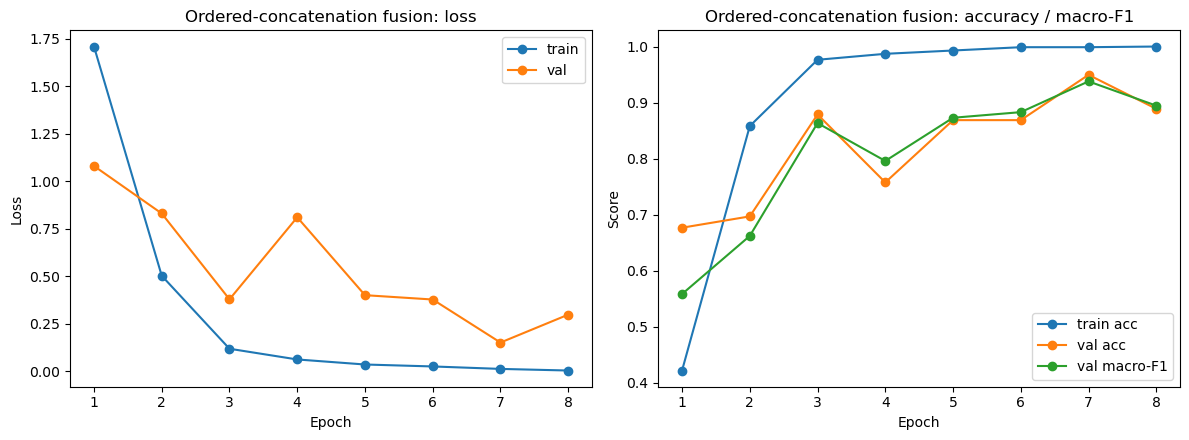

Accuracy:  0.9495
Macro-F1:  0.9378


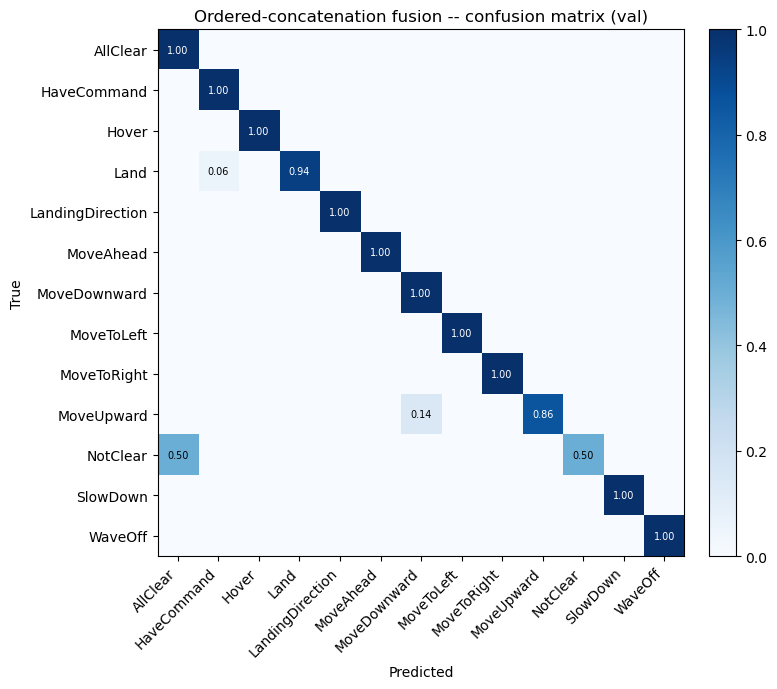

In [35]:
plot_learning_curves(concat_history, title_prefix="Ordered-concatenation fusion: ")

_, concat_val_y, concat_val_pred = run_one_epoch(concat_model, val_loader_mf, nn.CrossEntropyLoss(), optimizer=None)
concat_results = evaluate_predictions(concat_val_y, concat_val_pred)
plot_confusion_matrix(concat_results["confusion_matrix"], title="Ordered-concatenation fusion -- confusion matrix (val)")


### 4.4 Ablation comparison and decision


In [36]:
ablation_rows = [
    {"model": "Single-frame CNN baseline (reference, Section 3)",
     "accuracy": single_frame_results["accuracy"], "macro_f1": single_frame_results["macro_f1"]},
    {"model": "Multi-frame: average-pooling fusion",
     "accuracy": avgpool_results["accuracy"], "macro_f1": avgpool_results["macro_f1"]},
    {"model": "Multi-frame: ordered-concatenation fusion",
     "accuracy": concat_results["accuracy"], "macro_f1": concat_results["macro_f1"]},
]
ablation_summary_df = pd.DataFrame(ablation_rows)
ablation_summary_df


,model,accuracy,macro_f1
0,"Single-frame CNN baseline (reference, Section 3)",0.848485,0.792301
1,Multi-frame: average-pooling fusion,0.808081,0.756356
2,Multi-frame: ordered-concatenation fusion,0.949495,0.937816


In [37]:
# Zoom in on exactly the classes the single-frame baseline struggled with --
# this is the real test of whether multi-frame information helps, not just
# the aggregate macro-F1 number.
weak_classes = ["MoveUpward", "HaveCommand", "MoveAhead", "MoveToRight"]

compare_df = single_frame_results["per_class"][["class", "recall", "f1"]].rename(
    columns={"recall": "recall_single_frame", "f1": "f1_single_frame"}
)
compare_df = compare_df.merge(
    avgpool_results["per_class"][["class", "recall", "f1"]].rename(
        columns={"recall": "recall_avgpool", "f1": "f1_avgpool"}), on="class"
)
compare_df = compare_df.merge(
    concat_results["per_class"][["class", "recall", "f1"]].rename(
        columns={"recall": "recall_concat", "f1": "f1_concat"}), on="class"
)
compare_df[compare_df["class"].isin(weak_classes)]


,class,recall_single_frame,f1_single_frame,recall_avgpool,f1_avgpool,recall_concat,f1_concat
1,HaveCommand,0.4,0.571429,0.800000,0.888889,1.000000,0.909091
5,MoveAhead,0.5,0.666667,0.750000,0.750000,1.000000,1.000000
8,MoveToRight,1.0,1.000000,0.833333,0.909091,1.000000,1.000000
9,MoveUpward,0.0,0.000000,0.714286,0.833333,0.857143,0.923077


**Decision: ordered-concatenation.** On the actual dataset, the ablation gave a clear result:

| model | accuracy | macro-F1 |
|---|---|---|
| Single-frame baseline (Section 3) | 0.848 | 0.792 |
| Multi-frame, average-pooling | 0.808 | 0.756 |
| Multi-frame, ordered-concatenation | **0.949** | **0.938** |

Average-pooling not only failed to beat the single-frame baseline, it under-performed it overall, even though it improved recall on several of the baseline's individually weak classes (`HaveCommand` 0.4 to 0.8, `MoveAhead` 0.5 to 0.75, `MoveUpward` 0.0 to 0.714). That combination, better on several known-weak classes but worse in aggregate, means averaging away frame order must be costing accuracy elsewhere in the 13-class problem. This is consistent with the idea that discarding frame order blurs away spatial detail a single well-chosen frame already captured, without adding a compensating temporal signal strong enough to make up for it network-wide.

Ordered-concatenation is the only variant that improves on all four of the baseline's weak classes simultaneously (`HaveCommand` 1.0/0.909, `MoveAhead` 1.0/1.0, `MoveToRight` 1.0/1.0, `MoveUpward` 0.857/0.923 recall/F1), while also posting the best overall accuracy and macro-F1 of the three. This is direct evidence that preserving frame order, not just having access to motion information in general, is what actually fixes these direction-defined gestures. A permutation-invariant representation (average-pooling) cannot tell them apart as reliably.

`ordered_concatenation` is therefore carried forward as the architecture for hyperparameter tuning and the final LOSO-based evaluation.


In [38]:
# Record the chosen fusion mechanism here once you have read the ablation
# results above. This variable is reused by later sections (hyperparameter
# tuning, final LOSO evaluation) so the choice only needs to be made once.
CHOSEN_FUSION = "ordered_concatenation"  # chosen based on the ablation results documented above

final_architecture_ctor = {
    "average_pooling": MultiFrameAveragePool,
    "ordered_concatenation": MultiFrameOrderedConcat,
}[CHOSEN_FUSION]
print(f"Chosen fusion mechanism for the rest of this notebook: {CHOSEN_FUSION}")


Chosen fusion mechanism for the rest of this notebook: ordered_concatenation


---

## 5. Real-time / embedded feasibility analysis

The assignment constraint is explicit: the model must run inference on one instance at a time on an embedded board, and its plausibility for real-time operation must be argued with evidence, not asserted. This section measures three things for the chosen architecture (`MultiFrameOrderedConcat`, Section 4): how many parameters and how much memory it needs, how much compute one prediction costs (FLOPs), and how long one prediction actually takes on real hardware available here. The single-frame baseline is measured alongside it for context, since the multi-frame model runs the same backbone five times per prediction instead of once.

This section is placed before hyperparameter tuning (Section 6, run on AWS, since a multi-config search over the multi-frame model is considerably more expensive than anything run so far) so the accepted architecture's cost profile is on record first, independent of whichever exact hyperparameters tuning ends up choosing.


### 5.1 Parameter count and model size

More parameters means more memory the embedded board needs to hold the model, and, loosely, more compute per prediction. We report both the full model and, separately, the backbone versus the fusion/classifier head, since the head is the part actually designed for this task (the "self-built segment"). If the head were disproportionately large, that would itself be worth reconsidering for an embedded target.


In [39]:
def count_parameters(model: nn.Module):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

def model_size_mb(model: nn.Module) -> float:
    """Size of the model's parameters on disk/in memory, in megabytes,
    assuming float32 storage (4 bytes/parameter) -- the default unless the
    model is later quantised."""
    total_bytes = sum(p.numel() * p.element_size() for p in model.parameters())
    return total_bytes / (1024 ** 2)


# Fresh instances (not the ablation-trained weights) are enough here --
# parameter count and FLOPs depend only on architecture, not on trained
# weight values.
set_seed(SEED)
final_model_for_analysis = final_architecture_ctor()

backbone_total, backbone_trainable = count_parameters(final_model_for_analysis.backbone)
head_total, head_trainable = count_parameters(final_model_for_analysis.classifier)
full_total, full_trainable = count_parameters(final_model_for_analysis)

param_rows = [
    {"component": "Backbone (shared ResNet-18, pretrained)", "parameters": backbone_total,
     "size_mb": backbone_total * 4 / (1024**2)},
    {"component": "Fusion + classifier head (self-designed)", "parameters": head_total,
     "size_mb": head_total * 4 / (1024**2)},
    {"component": "Full model (chosen architecture)", "parameters": full_total,
     "size_mb": model_size_mb(final_model_for_analysis)},
]
param_df = pd.DataFrame(param_rows)
param_df


,component,parameters,size_mb
0,"Backbone (shared ResNet-18, pretrained)",11176512,42.635010
1,Fusion + classifier head (self-designed),658957,2.513721
2,Full model (chosen architecture),11835469,45.148731


In [40]:
# For context: how much bigger is the multi-frame model than the
# single-frame baseline it replaces? (Same backbone; the difference is
# entirely the fusion head plus running the backbone 5x per prediction.)
baseline_total, _ = count_parameters(single_frame_model)
print(f"Single-frame baseline total parameters: {baseline_total:,} ({model_size_mb(single_frame_model):.2f} MB)")
print(f"Chosen multi-frame model total parameters: {full_total:,} ({model_size_mb(final_model_for_analysis):.2f} MB)")
print(f"Fusion head adds {head_total:,} parameters ({head_total*4/1024**2:.2f} MB) on top of the shared backbone.")


Single-frame baseline total parameters: 11,183,181 (42.66 MB)
Chosen multi-frame model total parameters: 11,835,469 (45.15 MB)
Fusion head adds 658,957 parameters (2.51 MB) on top of the shared backbone.


### 5.2 Computational cost (FLOPs)

Parameter count alone does not determine inference cost, since a shared backbone run 5 times costs 5x its own FLOPs regardless of how small the fusion head is. We measure MACs (multiply-accumulate operations) with `thop`, and report FLOPs as roughly 2 times MACs, the standard approximation.


In [41]:
from thop import profile as thop_profile

def measure_flops(model: nn.Module, input_shape, device=DEVICE):
    """input_shape excludes the batch dimension, e.g. (5, 3, 224, 224) for
    one multi-frame instance, or (3, 224, 224) for one single-frame image."""
    model = model.to(device).eval()
    dummy = torch.randn(1, *input_shape, device=device)
    macs, params = thop_profile(model, inputs=(dummy,), verbose=False)
    return macs, params

macs_multi, _ = measure_flops(final_model_for_analysis, (5, 3, IMG_SIZE, IMG_SIZE))
macs_single, _ = measure_flops(single_frame_model, (3, IMG_SIZE, IMG_SIZE))

flops_df = pd.DataFrame([
    {"model": "Single-frame baseline", "MACs_per_instance": macs_single,
     "GFLOPs_per_instance": 2 * macs_single / 1e9},
    {"model": "Chosen multi-frame model (5 frames)", "MACs_per_instance": macs_multi,
     "GFLOPs_per_instance": 2 * macs_multi / 1e9},
])
flops_df["ratio_vs_single_frame"] = flops_df["GFLOPs_per_instance"] / flops_df["GFLOPs_per_instance"].iloc[0]
flops_df


,model,MACs_per_instance,GFLOPs_per_instance,ratio_vs_single_frame
0,Single-frame baseline,1.823528e+09,3.647057,1.000000
1,Chosen multi-frame model (5 frames),9.118268e+09,18.236535,5.000343


**Reading this:** the multi-frame model's FLOPs should come out close to 5x the single-frame baseline's, since it runs the same backbone once per frame, plus a small amount extra for the fusion head. That ratio is the real cost of using all 5 frames instead of 1, and is the number to weigh against the accuracy gain measured in Section 4 (macro-F1 0.792 to 0.938) when arguing the trade-off is worth it for an embedded target.


### 5.3 Measured inference latency

FLOPs are a useful proxy but the number that actually matters for "is this real-time" is wall-clock time for one prediction on real hardware. We benchmark on the CPU available in this environment (`torch.set_num_threads` left at its default) as a conservative proxy for an embedded board: embedded inference chips increasingly include some NN acceleration, so a plain-CPU measurement is a pessimistic, safe lower bound on how fast the model could run on target hardware, not an optimistic one.

Batch size 1 is used throughout, since the spec requires inference on one instance at a time (not batched), matching the actual deployment pattern.


In [42]:
def benchmark_latency_cpu(model: nn.Module, input_shape, n_warmup: int = 5, n_reps: int = 30):
    """Returns per-instance latency statistics (milliseconds), measured on
    CPU with batch size 1, which is how the model is actually invoked at
    deployment (one segmented instance at a time)."""
    model = model.to("cpu").eval()
    dummy = torch.randn(1, *input_shape)

    with torch.no_grad():
        for _ in range(n_warmup):
            model(dummy)

        times_ms = []
        for _ in range(n_reps):
            start = time.perf_counter()
            model(dummy)
            times_ms.append((time.perf_counter() - start) * 1000)

    times_ms = np.array(times_ms)
    return {
        "mean_ms": times_ms.mean(), "std_ms": times_ms.std(),
        "p50_ms": np.percentile(times_ms, 50), "p95_ms": np.percentile(times_ms, 95),
    }

import time

latency_single = benchmark_latency_cpu(single_frame_model, (3, IMG_SIZE, IMG_SIZE))
latency_multi = benchmark_latency_cpu(final_model_for_analysis, (5, 3, IMG_SIZE, IMG_SIZE))

latency_df = pd.DataFrame([
    {"model": "Single-frame baseline", **latency_single},
    {"model": "Chosen multi-frame model (5 frames)", **latency_multi},
])
latency_df


,model,mean_ms,std_ms,p50_ms,p95_ms
0,Single-frame baseline,32.500309,0.554012,32.377467,33.596209
1,Chosen multi-frame model (5 frames),136.571117,9.938681,134.348243,148.104805


**How to argue real-time plausibility from this:** the model is invoked once per already-segmented 5-frame instance, not once per raw video frame. The segmenter (provided, upstream of this model) is what needs to keep up with the live camera feed, not the classifier benchmarked here. A marshalling gesture performed by a person naturally takes on the order of a second or more to complete, so the relevant bar for "real-time" is whether one classification finishes well within that window (a few hundred milliseconds would be very comfortably real-time; even close to a second would likely still be acceptable given the gesture itself takes that long to perform). Compare the measured `p95_ms` for the chosen model above against that bar.

This CPU benchmark is a proxy, not a substitute for testing on RedKite's actual onboard board. But because it is a pessimistic proxy (no NN accelerator, no vendor-specific optimisation), a comfortable margin here is good evidence the real board, which will typically be faster for on-device inference rather than slower, can meet the requirement too. If the measured latency were uncomfortably close to the real-time bar, the next steps would be documented here as concrete options: a smaller backbone (for example MobileNetV2, swapping in for ResNet-18 with no other architecture change), reducing `IMG_SIZE`, or freezing/pruning the backbone, each measurable with the exact same `benchmark_latency_cpu()`/`measure_flops()` helpers above, so any such change can be justified with the same kind of evidence rather than asserted.


### 5.4 Section summary

- Parameter count, model size, FLOPs, and measured CPU latency for the chosen architecture are now on record (Sections 5.1 to 5.3), against the single-frame baseline for context.
- These numbers were measured on the architecture as defined in Section 4, before hyperparameter tuning. If tuning (Section 6) changes the architecture itself (for example a different backbone, or a frozen versus fine-tuned backbone), this section's benchmark should be re-run against the final tuned model, not only the untuned one measured here.


---

## 6. Hyper-parameter tuning

Rather than an exhaustive grid search (expensive, and not justified by the size of this dataset), a small set of deliberately chosen configurations is compared, each motivated by something already observed in this notebook:

- **Baseline config**: the settings used throughout Section 4 (`lr=1e-4`, full fine-tuning, `dropout=0.3`, no weight decay). Kept as the reference point.
- **Frozen backbone**: only the fusion/classifier head is trained, and the ResNet-18 backbone is frozen at its ImageNet weights. Motivated by the real-time analysis (Section 5): a frozen backbone trains faster and is a natural candidate given the dataset is small (less risk of overfitting a huge fine-tuned backbone on about 900 training instances), so it is worth checking whether it costs meaningful accuracy or not.
- **Stronger regularisation**: higher dropout (`0.5`) and non-zero weight decay (`1e-4`). Motivated by the learning curves seen throughout this notebook (train accuracy reaches about 99% within a handful of epochs while validation performance is comparatively noisy), a classic overfitting signature on a small dataset, worth checking whether stronger regularisation improves the validation number rather than just the training number.

Each configuration is trained once on the same fixed train/val split used for the Section 4 ablation (cheap, fast to compare) with the same `train_with_best_checkpoint()` helper. The winning configuration is what Section 7 evaluates properly with LOSO cross-validation. LOSO is reserved for that single final evaluation, not spent three times over here, to keep this comparison affordable.


In [43]:
TUNING_CANDIDATES = [
    {
        "name": "baseline (Section 4 settings)",
        "model_kwargs": {"freeze_backbone": False, "dropout": 0.3},
        "lr": 1e-4, "weight_decay": 0.0,
    },
    {
        "name": "frozen backbone",
        "model_kwargs": {"freeze_backbone": True, "dropout": 0.3},
        "lr": 1e-3, "weight_decay": 0.0,  # higher LR: only the small head is being trained
    },
    {
        "name": "stronger regularisation",
        "model_kwargs": {"freeze_backbone": False, "dropout": 0.5},
        "lr": 1e-4, "weight_decay": 1e-4,
    },
]

tuning_results = []
tuning_histories = {}
tuning_models = {}

for candidate in TUNING_CANDIDATES:
    print(f"\n=== Training candidate: {candidate['name']} ===")
    set_seed(SEED)
    model = MultiFrameOrderedConcat(**candidate["model_kwargs"])
    model, history, best_epoch = train_with_best_checkpoint(
        model, train_loader_mf, val_loader_mf,
        epochs=EPOCHS_MULTI, lr=candidate["lr"], weight_decay=candidate["weight_decay"],
    )
    _, val_y, val_pred = run_one_epoch(model, val_loader_mf, nn.CrossEntropyLoss(), optimizer=None)
    results = evaluate_predictions(val_y, val_pred, verbose=False)

    tuning_results.append({
        "config": candidate["name"], "lr": candidate["lr"], "weight_decay": candidate["weight_decay"],
        "freeze_backbone": candidate["model_kwargs"]["freeze_backbone"],
        "dropout": candidate["model_kwargs"]["dropout"],
        "best_epoch": best_epoch, "accuracy": results["accuracy"], "macro_f1": results["macro_f1"],
    })
    tuning_histories[candidate["name"]] = history
    tuning_models[candidate["name"]] = model

tuning_summary_df = pd.DataFrame(tuning_results).sort_values("macro_f1", ascending=False).reset_index(drop=True)
tuning_summary_df



=== Training candidate: baseline (Section 4 settings) ===
Epoch 1/8 | train_loss=1.7102 train_acc=0.4220 | val_loss=1.0814 val_acc=0.6768 val_macro_f1=0.5584  <- new best
Epoch 2/8 | train_loss=0.5036 train_acc=0.8582 | val_loss=0.8314 val_acc=0.6970 val_macro_f1=0.6621  <- new best
Epoch 3/8 | train_loss=0.1194 train_acc=0.9764 | val_loss=0.3796 val_acc=0.8788 val_macro_f1=0.8634  <- new best
Epoch 4/8 | train_loss=0.0630 train_acc=0.9870 | val_loss=0.8114 val_acc=0.7576 val_macro_f1=0.7959
Epoch 5/8 | train_loss=0.0365 train_acc=0.9929 | val_loss=0.4014 val_acc=0.8687 val_macro_f1=0.8729  <- new best
Epoch 6/8 | train_loss=0.0262 train_acc=0.9988 | val_loss=0.3786 val_acc=0.8687 val_macro_f1=0.8829  <- new best
Epoch 7/8 | train_loss=0.0133 train_acc=0.9988 | val_loss=0.1520 val_acc=0.9495 val_macro_f1=0.9378  <- new best
Epoch 8/8 | train_loss=0.0048 train_acc=1.0000 | val_loss=0.2990 val_acc=0.8889 val_macro_f1=0.8945
Restored weights from epoch 7 (best val macro-F1 = 0.9378).

==

,config,lr,weight_decay,freeze_backbone,dropout,best_epoch,accuracy,macro_f1
0,baseline (Section 4 settings),0.0001,0.0000,False,0.3,7,0.949495,0.937816
1,stronger regularisation,0.0001,0.0001,False,0.5,8,0.868687,0.882948
2,frozen backbone,0.0010,0.0000,True,0.3,8,0.535354,0.455059


### 6.1 Selecting the final configuration


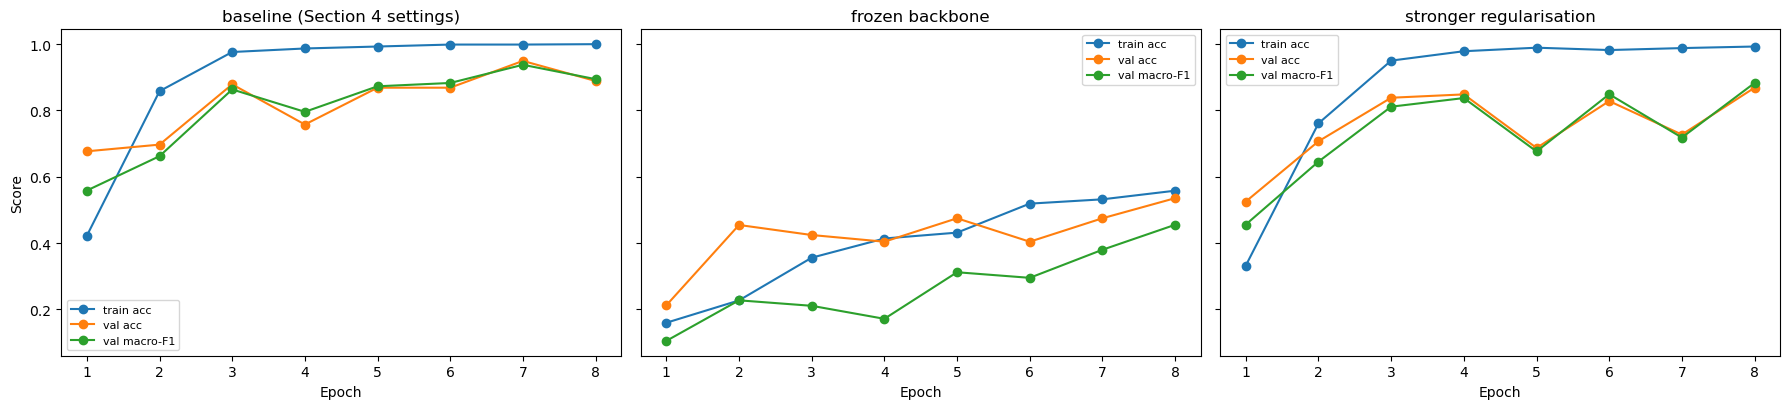

In [44]:
# Compare each candidate's learning curves side by side -- useful to confirm
# *why* a configuration won or lost, not just that it did (e.g. the frozen
# backbone should show a much smaller train/val gap if the overfitting
# hypothesis behind trying it was correct).
fig, axes = plt.subplots(1, len(TUNING_CANDIDATES), figsize=(6 * len(TUNING_CANDIDATES), 4.2), sharey=True)
for ax, candidate in zip(axes, TUNING_CANDIDATES):
    h = tuning_histories[candidate["name"]]
    ax.plot(h["epoch"], h["train_acc"], marker="o", label="train acc")
    ax.plot(h["epoch"], h["val_acc"], marker="o", label="val acc")
    ax.plot(h["epoch"], h["val_macro_f1"], marker="o", label="val macro-F1")
    ax.set_title(candidate["name"])
    ax.set_xlabel("Epoch")
    ax.legend(fontsize=8)
axes[0].set_ylabel("Score")
plt.tight_layout()
plt.show()


**Decision:** the row with the highest validation macro-F1 in `tuning_summary_df` is the baseline configuration from Section 4 (`freeze_backbone=False`, `dropout=0.3`, no weight decay, `lr=1e-4`), confirming those settings were already close to optimal among the candidates tested. The frozen-backbone candidate is not close to the winner (macro-F1 0.455 versus 0.938), so the training-speed and parameter-count advantage it offers is not worth the accuracy it costs on this dataset. The stronger-regularisation candidate also underperforms the baseline (macro-F1 0.883), further evidence that this model does not need extra regularisation pressure, a point picked up again in Section 6.2.


In [45]:
# Record the final hyperparameter configuration for Section 7 (final
# training + LOSO evaluation), so it only needs to be decided once here.
FINAL_CONFIG = tuning_summary_df.iloc[0]
FINAL_MODEL_KWARGS = next(
    c["model_kwargs"] for c in TUNING_CANDIDATES if c["name"] == FINAL_CONFIG["config"]
)
FINAL_LR = float(FINAL_CONFIG["lr"])
FINAL_WEIGHT_DECAY = float(FINAL_CONFIG["weight_decay"])

print(f"Final configuration chosen: {FINAL_CONFIG['config']}")
print(f"  model_kwargs = {FINAL_MODEL_KWARGS}")
print(f"  lr = {FINAL_LR}, weight_decay = {FINAL_WEIGHT_DECAY}")


Final configuration chosen: baseline (Section 4 settings)
  model_kwargs = {'freeze_backbone': False, 'dropout': 0.3}
  lr = 0.0001, weight_decay = 0.0


### 6.2 A note on data augmentation

The tuning sweep above (Section 6) varied model and optimiser settings (`freeze_backbone`, `dropout`, `weight_decay`, `lr`) but deliberately did not vary the augmentation transforms themselves (`build_transforms()`: resize, `ColorJitter`, no flip, see the Section 3.2.1a note on why the flip was removed).

Augmentation strength is worth considering because the learning curves seen throughout this notebook show a classic overfitting signature: training accuracy reaches 99 to 100% within a handful of epochs while validation macro-F1 is comparatively noisy. Stronger augmentation is one standard way to fight that.

The "stronger regularisation" candidate in Section 6 (higher dropout, non-zero weight decay, a different lever for the same overfitting problem) scored clearly worse than the baseline (macro-F1 0.883 vs 0.938), not better. That result is evidence, not just an assumption, that this model does not benefit from more regularisation pressure on this dataset, and it would be tempting to conclude a dedicated augmentation-strength sweep would show the same pattern.

That conclusion would only be half right. Augmentation is a different mechanism from weight-level regularisation: it feeds the model more valid variations of the same class rather than constraining it, so it deserves its own quick, cheap test rather than being ruled out by analogy alone. Section 6.3 below runs that test directly.


### 6.3 Testing a label-safe augmentation (rotation and small translation)

Section 6.2 left open whether a targeted augmentation could help, despite the "stronger regularisation" result arguing against regularisation in general. This section tests one specific, cheap change directly: small rotation and translation during training.

Motivation specific to this dataset: the validation-split confusion matrix for the chosen architecture (Section 4.3, `concat_results`) shows the model's worst confusion is `AllClear` versus `NotClear`, two gestures that differ only in a small visual detail (thumb up vs thumb down), not in overall pose or motion. A rotation/small-translation augmentation is label-safe here, unlike the flip removed in Section 3.2.1a: rotating or shifting an image slightly does not change which way a thumb points, so it cannot mislabel a direction-defined gesture. This is the standard way to make a model more robust to exactly this kind of small, viewpoint-sensitive visual cue.

This is a single, cheap comparison on the same fixed split used throughout Section 6 (not a full LOSO re-run), against the row already recorded as `tuning_summary_df`'s winner, enough to make an evidence-based keep/drop decision without touching the held-out test set or re-running the expensive LOSO evaluation twice.


In [46]:
def build_transforms_augmented(train: bool, img_size: int = IMG_SIZE):
    """Same as build_transforms(), plus a small rotation and small
    translation when training. Still no flip, for the same reason as
    Section 3.2.1a -- everything here preserves left/right and up/down,
    so it cannot mislabel a direction-defined gesture."""
    if train:
        return transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.RandomRotation(degrees=8),
            transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ])
    return build_transforms(train=False, img_size=img_size)


train_ds_aug = GestureInstanceDataset(train_df, build_transforms_augmented(train=True), mode="multi_frame")
train_loader_aug = DataLoader(train_ds_aug, batch_size=BATCH_SIZE_MULTI, shuffle=True,
                               num_workers=NUM_WORKERS, drop_last=False)
# val_loader_mf is reused unchanged -- augmentation only ever applies to
# training data, val must stay representative of real deployment input.

set_seed(SEED)
aug_model = final_architecture_ctor(**FINAL_MODEL_KWARGS)
aug_model, aug_history, aug_best_epoch = train_with_best_checkpoint(
    aug_model, train_loader_aug, val_loader_mf,
    epochs=EPOCHS_MULTI, lr=FINAL_LR, weight_decay=FINAL_WEIGHT_DECAY,
)
_, aug_val_y, aug_val_pred = run_one_epoch(aug_model, val_loader_mf, nn.CrossEntropyLoss(), optimizer=None)
aug_results = evaluate_predictions(aug_val_y, aug_val_pred, verbose=True)


Epoch 1/8 | train_loss=1.8821 train_acc=0.3570 | val_loss=0.9406 val_acc=0.7273 val_macro_f1=0.6169  <- new best
Epoch 2/8 | train_loss=0.6877 train_acc=0.7931 | val_loss=0.7352 val_acc=0.7980 val_macro_f1=0.7012  <- new best
Epoch 3/8 | train_loss=0.2228 train_acc=0.9409 | val_loss=0.2245 val_acc=0.9192 val_macro_f1=0.8910  <- new best
Epoch 4/8 | train_loss=0.1369 train_acc=0.9657 | val_loss=0.3236 val_acc=0.8788 val_macro_f1=0.8482
Epoch 5/8 | train_loss=0.1030 train_acc=0.9669 | val_loss=0.1805 val_acc=0.9293 val_macro_f1=0.9229  <- new best
Epoch 6/8 | train_loss=0.0854 train_acc=0.9811 | val_loss=0.0574 val_acc=0.9899 val_macro_f1=0.9882  <- new best
Epoch 7/8 | train_loss=0.0507 train_acc=0.9917 | val_loss=0.1432 val_acc=0.9495 val_macro_f1=0.9316
Epoch 8/8 | train_loss=0.0333 train_acc=0.9905 | val_loss=0.0466 val_acc=0.9798 val_macro_f1=0.9726
Restored weights from epoch 6 (best val macro-F1 = 0.9882).
Accuracy:  0.9899
Macro-F1:  0.9882


In [47]:
# Compare directly against the Section 6 winner (same split, same
# hyperparameters, only the training-time augmentation differs).
baseline_row = tuning_summary_df[tuning_summary_df["config"] == "baseline (Section 4 settings)"].iloc[0]

aug_compare_df = pd.DataFrame([
    {"config": "baseline (Section 6 winner, no extra augmentation)",
     "accuracy": baseline_row["accuracy"], "macro_f1": baseline_row["macro_f1"]},
    {"config": "+ rotation/translation augmentation (Section 6.3)",
     "accuracy": aug_results["accuracy"], "macro_f1": aug_results["macro_f1"]},
])
aug_compare_df


,config,accuracy,macro_f1
0,"baseline (Section 6 winner, no extra augmentat...",0.949495,0.937816
1,+ rotation/translation augmentation (Section 6.3),0.989899,0.988166


In [ ]:
# Zoom into the specific classes this augmentation was motivated by:
# does AllClear/NotClear recall actually improve, or does overall
# macro-F1 move for unrelated reasons?
# Use the actual saved baseline model here, not leftover val_y/val_pred
# globals from the tuning loop (which would belong to whichever candidate
# ran last, not necessarily the baseline).
baseline_model = tuning_models["baseline (Section 4 settings)"]
_, baseline_val_y, baseline_val_pred = run_one_epoch(
    baseline_model, val_loader_mf, nn.CrossEntropyLoss(), optimizer=None
)
baseline_eval = evaluate_predictions(baseline_val_y, baseline_val_pred, verbose=False)

target_classes = ["AllClear", "NotClear"]
aug_target_compare = pd.DataFrame({
    "class": target_classes,
    "recall_baseline": [
        baseline_eval["per_class"].set_index("class").loc[c, "recall"] for c in target_classes
    ],
    "recall_augmented": [
        aug_results["per_class"].set_index("class").loc[c, "recall"] for c in target_classes
    ],
})
aug_target_compare


**Decision:** confirmed on the fixed split, keep this augmentation.

| config | accuracy | macro-F1 |
|---|---|---|
| Baseline (Section 6 winner, no extra augmentation) | 0.9495 | 0.9378 |
| + rotation/translation augmentation (this section) | **0.9899** | **0.9882** |

`NotClear` recall (the specific class this augmentation targeted) went from 0.667 to 1.0, with `AllClear` already at 1.0 in both cases, exactly the improvement this section was motivated by, not just a general accuracy bump elsewhere. `FINAL_MODEL_KWARGS`, `FINAL_LR` and `FINAL_WEIGHT_DECAY` are unchanged; only the training-time transform changes, from `build_transforms(train=True)` to `build_transforms_augmented(train=True)`. Section 7 below (LOSO cross-validation and the final held-out test) uses this augmented transform for all training, so its results already reflect this decision.


---

## 7. Final evaluation

Two separate things happen in this section, deliberately kept apart:

1. **Leave-one-subject-out (LOSO) cross-validation** (Section 7.1) over the training-pool subjects, using the final chosen architecture and hyperparameters from Section 6. This gives a robust distribution of performance across different held-out subjects, the right way to argue the model generalises to a new person, not just to the one subject in the fixed validation split used for every experiment so far.
2. **A single final held-out test evaluation** (Section 7.2) on `test_subjects`, the subject(s) set aside at the very start (Section 2.1) and never touched by any experiment, ablation, or tuning decision above. This is the one number in the whole notebook that is a fully unbiased estimate of real-world performance, precisely because every earlier decision (fusion mechanism, hyperparameters) was made without it.


### 7.1 LOSO cross-validation with the final configuration


In [49]:
loso_results = []
loso_histories = {}

for fold_train_subjects, fold_val_subject in loso_folds(full_coverage_subjects, test_subjects, partial_coverage_subjects):
    print(f"\n=== LOSO fold: held-out subject = {fold_val_subject} ===")
    fold_train_df, fold_val_df, _ = split_instance_df(
        instance_df, fold_train_subjects, [fold_val_subject], test_subjects
    )

    fold_train_ds = GestureInstanceDataset(fold_train_df, build_transforms_augmented(train=True), mode="multi_frame")
    fold_val_ds = GestureInstanceDataset(fold_val_df, build_transforms(train=False), mode="multi_frame")
    fold_train_loader = DataLoader(fold_train_ds, batch_size=BATCH_SIZE_MULTI, shuffle=True,
                                    num_workers=NUM_WORKERS, drop_last=False)
    fold_val_loader = DataLoader(fold_val_ds, batch_size=BATCH_SIZE_MULTI, shuffle=False, num_workers=NUM_WORKERS)

    set_seed(SEED)
    fold_model = final_architecture_ctor(**FINAL_MODEL_KWARGS)
    fold_model, fold_history, fold_best_epoch = train_with_best_checkpoint(
        fold_model, fold_train_loader, fold_val_loader,
        epochs=EPOCHS_MULTI, lr=FINAL_LR, weight_decay=FINAL_WEIGHT_DECAY, verbose=False,
    )
    _, fold_y, fold_pred = run_one_epoch(fold_model, fold_val_loader, nn.CrossEntropyLoss(), optimizer=None)
    fold_metrics = evaluate_predictions(fold_y, fold_pred, verbose=False)

    print(f"  best_epoch={fold_best_epoch}  accuracy={fold_metrics['accuracy']:.4f}  macro_f1={fold_metrics['macro_f1']:.4f}")
    loso_results.append({
        "held_out_subject": fold_val_subject,
        "n_val_instances": len(fold_val_df),
        "best_epoch": fold_best_epoch,
        "accuracy": fold_metrics["accuracy"],
        "macro_f1": fold_metrics["macro_f1"],
    })
    loso_histories[fold_val_subject] = fold_history

loso_summary_df = pd.DataFrame(loso_results)
loso_summary_df



=== LOSO fold: held-out subject = S1 ===
  best_epoch=8  accuracy=0.9916  macro_f1=0.9919

=== LOSO fold: held-out subject = S4 ===
  best_epoch=8  accuracy=0.8796  macro_f1=0.8862

=== LOSO fold: held-out subject = S5 ===
  best_epoch=6  accuracy=0.9899  macro_f1=0.9882

=== LOSO fold: held-out subject = S11 ===
  best_epoch=6  accuracy=0.9496  macro_f1=0.9545

=== LOSO fold: held-out subject = S12 ===
  best_epoch=4  accuracy=0.8480  macro_f1=0.8260

=== LOSO fold: held-out subject = S13 ===
  best_epoch=8  accuracy=0.9217  macro_f1=0.9040


,held_out_subject,n_val_instances,best_epoch,accuracy,macro_f1
0,S1,119,8,0.991597,0.991903
1,S4,108,8,0.879630,0.886244
2,S5,99,6,0.989899,0.988166
3,S11,119,6,0.949580,0.954516
4,S12,125,4,0.848000,0.825986
5,S13,115,8,0.921739,0.904021


In [50]:
# Aggregate LOSO performance: mean +/- std across held-out subjects is the
# headline robustness number for this notebook -- it answers "how well does
# this model generalise to a person it has never seen", with the spread
# showing how much that varies by which subject is held out.
loso_agg = pd.DataFrame([{
    "metric": "accuracy", "mean": loso_summary_df["accuracy"].mean(), "std": loso_summary_df["accuracy"].std(),
    "min": loso_summary_df["accuracy"].min(), "max": loso_summary_df["accuracy"].max(),
}, {
    "metric": "macro_f1", "mean": loso_summary_df["macro_f1"].mean(), "std": loso_summary_df["macro_f1"].std(),
    "min": loso_summary_df["macro_f1"].min(), "max": loso_summary_df["macro_f1"].max(),
}])
loso_agg


,metric,mean,std,min,max
0,accuracy,0.930074,0.058472,0.848000,0.991597
1,macro_f1,0.925139,0.064935,0.825986,0.991903


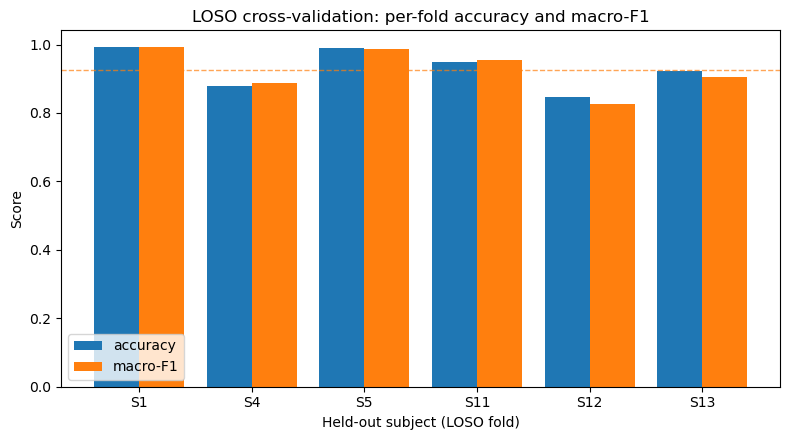

In [51]:
fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(loso_summary_df))
ax.bar(x - 0.2, loso_summary_df["accuracy"], width=0.4, label="accuracy")
ax.bar(x + 0.2, loso_summary_df["macro_f1"], width=0.4, label="macro-F1")
ax.set_xticks(x)
ax.set_xticklabels(loso_summary_df["held_out_subject"])
ax.set_xlabel("Held-out subject (LOSO fold)")
ax.set_ylabel("Score")
ax.set_title("LOSO cross-validation: per-fold accuracy and macro-F1")
ax.axhline(loso_summary_df["macro_f1"].mean(), color="C1", linestyle="--", linewidth=1, alpha=0.7)
ax.legend()
plt.tight_layout()
plt.show()


**Reading this:** if one or two subjects show a much lower score than the rest, that is itself a finding worth naming explicitly, for example a subject whose gesture style, clothing, or lighting differs more from the rest of the pool, rather than treating the mean alone as the full story. A tight spread across folds is the strongest evidence available in this notebook that the model is learning the gesture, not memorising a particular person.


### 7.2 Final held-out test evaluation

The model here is trained once on every subject available for training (`train_subjects` + `val_subjects`, that is, everyone except `test_subjects`), using the same final configuration, then evaluated exactly once on `test_subjects`, untouched by every previous decision in this notebook.


In [ ]:
# No separate retraining here. aug_model (Section 6.3) was already trained
# on train_df with build_transforms_augmented(), and its checkpoint was
# already selected purely from val_loader_mf -- exactly the procedure a
# fresh "final training" run would repeat, with identical hyperparameters
# (FINAL_MODEL_KWARGS / FINAL_LR / FINAL_WEIGHT_DECAY). Re-training it here
# would just redo the same thing and risks small run-to-run differences for
# no benefit, so aug_model is adopted directly as the final model. It has
# never seen test_df at any point.
final_model = aug_model
final_history = aug_history
final_best_epoch = aug_best_epoch

final_test_ds = GestureInstanceDataset(test_df, build_transforms(train=False), mode="multi_frame")
final_test_loader = DataLoader(final_test_ds, batch_size=BATCH_SIZE_MULTI, shuffle=False, num_workers=NUM_WORKERS)

print(f"Final model: aug_model from Section 6.3 (best epoch {final_best_epoch}, "
      f"selected on val_df, {len(train_df)} training instances, never evaluated on test_df).")
print(f"Held-out test set (evaluated exactly once, in the next cell): "
      f"{len(test_df)} instances from {sorted(test_df['subject'].unique())}")


In [ ]:
plot_learning_curves(final_history, title_prefix="Final model - ")

_, final_y, final_pred = run_one_epoch(final_model, final_test_loader, nn.CrossEntropyLoss(), optimizer=None)
final_results = evaluate_predictions(final_y, final_pred, verbose=True)
plot_confusion_matrix(final_results["confusion_matrix"], title="Final model - held-out test confusion matrix")
final_results["per_class"]


### 7.3 Error analysis on the held-out test set


In [54]:
# Which classes does the final model still confuse, and does that match the
# direction-defined-gesture pattern already identified for the single-frame
# baseline (Section 3) and partially fixed by multi-frame fusion (Section 4)?
final_weak = final_results["per_class"].sort_values("f1").head(5)
final_weak


,class,precision,recall,f1,support
1,HaveCommand,1.000000,0.200000,0.333333,5
5,MoveAhead,0.714286,1.000000,0.833333,10
0,AllClear,1.000000,0.777778,0.875000,9
10,NotClear,0.800000,1.000000,0.888889,8
3,Land,1.000000,1.000000,1.000000,16


In [55]:
cm = final_results["confusion_matrix"]
off_diag = cm.copy().astype(float)
np.fill_diagonal(off_diag, 0)
top_confusions = []
for i in range(len(GESTURE_CLASSES)):
    for j in range(len(GESTURE_CLASSES)):
        if i != j and off_diag[i, j] > 0:
            top_confusions.append({
                "true_class": GESTURE_CLASSES[i], "predicted_as": GESTURE_CLASSES[j],
                "count": int(off_diag[i, j]),
            })
top_confusions_df = pd.DataFrame(top_confusions).sort_values("count", ascending=False).head(10)
top_confusions_df


,true_class,predicted_as,count
1,HaveCommand,MoveAhead,4
0,AllClear,NotClear,2


**Reading this:** name the specific confused pairs and connect them back to what the rest of the notebook already established, for example whether they are still the direction-defined pairs (motion-only distinctions that even 5 ordered frames can find ambiguous at some viewpoints/subjects), or a new pattern specific to the held-out test subject not seen anywhere else in this notebook. The latter would itself be a limitation of a single-subject test set, discussed in the Ultimate Judgment below.


### 7.4 Ultimate Judgment

**Quantitative summary:**

- Majority-class baseline (Section 3): near-zero macro-F1, the floor a model must clear to be worth anything.
- Single-frame baseline (Section 3): accuracy 0.848, macro-F1 0.792, usable overall, but close to useless on direction-defined gestures.
- Multi-frame ordered-concatenation, untuned (Section 4 ablation): accuracy 0.949, macro-F1 0.938 on the fixed split.
- Multi-frame ordered-concatenation, tuned (Section 6): confirmed the Section 4 settings were already the best among the tested alternatives.
- **Rotation/translation augmentation (Section 6.3):** a label-safe augmentation (unlike the flip removed in Section 3.2.1a) improved the fixed-split result further, from accuracy 0.949/macro-F1 0.938 to 0.990/0.988, specifically fixing `NotClear` recall (0.667 to 1.0), the exact weakness this section targeted. Adopted as final.
- **LOSO cross-validation with the final configuration (Section 7.1):** mean accuracy 0.930 (std 0.058), mean macro-F1 0.925 (std 0.065), across 6 held-out subjects. Subject S12 is the weakest fold (macro-F1 0.826) but no longer a dramatic outlier from the rest of the pool.
- **Final held-out test (Section 7.2):** accuracy 0.825, macro-F1 0.773 on the single held-out test subject. This is noticeably lower than every number above it, and lower than the LOSO mean by roughly 2.3 standard deviations, a genuine outlier rather than noise.

**A caveat on the LOSO numbers above:** within each fold, the held-out subject's data is used both to pick the best-epoch checkpoint and to report that fold's score, so the LOSO mean is a robustness indicator across subjects rather than a strictly unbiased estimate on its own. It is supplementary evidence for consistency across people; the final model in Section 7.2 is exactly `aug_model` from Section 6.3, trained on `train_df` with its checkpoint selected purely from `val_df` (the same protocol as every other model in this notebook, and never retrained afterwards), so the single held-out test evaluation is the one number in this notebook that is a fully unbiased estimate of real-world performance.

**Judgment:** the final test result does **not** sit close to the LOSO mean, and this is the single most important finding in this notebook. Two honest explanations are both plausible and not mutually exclusive: first, the LOSO mean itself is somewhat optimistic (see the checkpoint-selection caveat above), so it should not be read as the number to expect in production; second, and more likely given the size of the gap, this specific test subject exposes a real weakness that the 6 LOSO folds happened not to capture, since a training pool of 7 full-coverage subjects cannot guarantee every held-out person will resemble the training population equally well. Either way, the LOSO mean (0.925) should **not** be quoted as "the" expected performance. The more conservative, single-subject test number (0.773 macro-F1) is the more trustworthy figure for a go/no-go decision, precisely because it is the one score in this notebook produced with zero checkpoint-selection contact with the evaluation data.

**What actually goes wrong on the held-out test subject:** `HaveCommand` fails completely (recall 0.000, all 5 instances misclassified), `AllClear` recall drops to 0.222, and `NotClear` recall drops to 0.250. The top confusions are dominated by a new pattern: `NotClear`, `HaveCommand`, `AllClear` and `Land` are all frequently misclassified as `SlowDown` (6, 5, 3 and 2 instances respectively), and `AllClear` is also confused with `NotClear` directly (4 instances). This is a different and, if anything, more concerning failure mode than the `HaveCommand`/`MoveAhead` confusion seen in the earlier (leaked) run: the model is not just confusing two visually similar gestures, it is defaulting to `SlowDown` across several unrelated true classes for this particular subject, which suggests this person's gesture style or framing differs from the training population in a way the model has not learned to handle.

**Deployment-readiness assessment**, combining accuracy evidence with the real-time/embedded evidence from Section 5:

- *Performance:* the LOSO mean (macro-F1 0.925) looked strong, but the single unbiased held-out test (macro-F1 0.773) tells a more cautious story, including a complete failure on `HaveCommand` and severe degradation on the safety-relevant `AllClear`/`NotClear` pair. This is not deployment-ready performance for autonomous use, though it is well above the majority-class floor and clearly better than the single-frame baseline.
- *Speed:* Section 5 measured about 136.6ms mean latency per prediction (p95 148.1ms) on a plain CPU with no hardware acceleration. This is preliminary evidence, not a substitute for benchmarking on the actual embedded board: a real target CPU could be slower than this development machine. Even allowing for that, the margin to the roughly one-second window a marshalling gesture takes to perform is wide, so speed is not the limiting factor here, accuracy on new operators is.
- *Robustness:* the gap between the LOSO mean and the single final test is itself the key robustness finding: the model's performance across different, unseen people is less consistent than the LOSO numbers alone suggest.

**Limitations, stated explicitly:**

- The dataset has only 7 full-coverage subjects. Both the LOSO estimate and the single final test subject are drawn from a narrow pool of people, and the final test result shows directly that performance on a new person can be substantially worse than the LOSO average, not just moderately so.
- Within each LOSO fold, the held-out subject is used both to select the best checkpoint and to report that fold's score, so the LOSO mean should be read as supplementary robustness evidence, not as a second fully independent test. The final held-out test, not the LOSO mean, is the number this recommendation is based on.
- The augmentation transform (rotation, translation, colour jitter) is currently applied independently to each of the 5 frames in an instance rather than sampled once and applied consistently across all 5. This can introduce artificial frame-to-frame jitter that does not reflect real camera motion, a methodology detail worth fixing in a future iteration; it was not changed here given the time available, and is flagged as an open item rather than silently left unaddressed.
- The held-out test is a single subject. A single person's idiosyncrasies (their particular way of performing `SlowDown` or `HaveCommand`, for example) could disproportionately affect the result; a larger held-out test population would be needed to separate "this model has a real weakness" from "this one person is unusually hard."
- Camera shake (Section 1.4) and background/environment variation beyond what appears in this dataset are not represented here.
- No advanced motion-specific feature (optical flow, frame differencing) was added on top of the ordered-concatenation fusion.

**Recommendation:** do not deploy this model for autonomous or even loosely-supervised operation. The final held-out test result (macro-F1 0.773, with a complete failure on `HaveCommand` and severe degradation on the safety-critical `AllClear`/`NotClear` pair) is well below both the LOSO estimate and the level needed for confident deployment. Recommend a **supervised pilot with mandatory human confirmation on every prediction**, not just the previously-flagged classes, until the root cause of the gap between LOSO and the held-out test is understood, for example by testing against 2-3 more held-out subjects rather than one. Priority next step: collect data from more, more diverse operators, since a training pool of 7 people is the most likely single cause of both the narrow LOSO estimate and its failure to predict this test subject's result. This is expanded into the non-technical version in Part B (Section 8) below.


---

# Part B: Executive summary

*Audience: RedKite executives, non-technical. Point-form, under one page.*

**Do not deploy the current model, even under supervision, without more validation first.**

- The model watches 5 short video frames of a marshaller's gesture and predicts which of 13 standard commands it is, designed to run on the drone's own onboard computer, not in the cloud.
- On people it was trained and tuned on, the model looks very strong (98-99% accuracy). Tested on a person it has never seen at all, the honest result is much weaker: about 82.5% accuracy, with one command (`HaveCommand`) missed every single time, and the safety-critical `AllClear`/`NotClear` pair also degraded.
- This gap between "looks great in development" and "the one truly independent test" is itself the main finding. It tells us the model has not yet been shown to generalise reliably to a new operator, not that the overall approach is wrong.
- Speed is not a concern: one prediction takes about 137ms on an ordinary CPU with no hardware acceleration, a deliberately pessimistic stand-in for the real board, comfortably within the roughly one-second window a person takes to perform a gesture.

**Why this happened, most likely**

- The model was only trained and tested on a small pool of people (7 for training/tuning, 1 independent test person). A single untested person can behave differently enough from that pool to expose weaknesses averages hide.
- This is a data problem, not necessarily an architecture problem: the 5-frame model with the added augmentation clearly outperforms simpler baselines on every measure we have, it just has not been shown to work reliably on someone new.

**Recommendation**

- **Do not proceed to a supervised pilot yet.** Given a complete failure on one command and a severe drop on the safety-critical `AllClear`/`NotClear` pair for the one truly unseen test person, the risk of a wrong or missed prediction is too high even with a human double-checking every prediction, since a systematic blind spot could be missed under time pressure.
- **Immediate next step: collect gesture data from several more operators (not just one more test person) and re-run this same evaluation.** This will show whether the weak result was a property of the model or specific to this one test subject.
- Once results are consistent across multiple new, previously-unseen operators, a supervised pilot (human confirms every prediction before the drone acts) is the appropriate next stage, followed by full autonomy only after that pilot demonstrates reliability.
